<a href="https://colab.research.google.com/github/LucasBarbosaSilva/MVPSprint2AnalisePreProcessamento/blob/main/MVP_Sprint_2_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Barbosa Leite Silva

**Matrícula:** 4052025002093

**Dataset:** [Marketing bancário](https://archive.ics.uci.edu/dataset/222/bank+marketing)

# Descrição do Problema

Os dados referem-se a campanhas de marketing direto (chamadas telefônicas) de uma instituição bancária portuguesa. O objetivo da classificação é prever se o cliente irá se inscrever em um depósito a prazo (variável result).

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?
2. Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?
3. Ligar mais vezes para um cliente diminui a chance dele contratar?
4. Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características, (como idade, número de ligações, dias entre as ligações, ocupação e nível de escolaridade), o objetivo é prever qual o resultado final do contato (yes/no).

## Seleção de Dados

O dataset Bank Marketing é um dataset disponível no UCI Machine Learning Repository. Os dados referem-se a campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas de marketing baseavam-se em chamadas telefónicas. Frequentemente, era necessário mais do que um contacto com o mesmo cliente para apurar se o produto (depósito a prazo bancário) seria contratado ("sim") ou não ("não"). O dataset é composto por 45211 instâncias e 17 colunas.

## Atributos do Dataset

O dataset Bank Marketing contém 45211 amostras, cada uma com 17 atributos (16 features e 1 target):

| Variável | Descrição | Tipo | Categorias |
|---       | ---       | ---  | ---        |
| **age**  | idade     | numérica | N/A    |
| **job**  | ocupação  | categórica | admin., blue-collar, entrepneur housemaid, management, retired, self-employed, services, student, <br>technician, unemployed, unknown |
| **marital** | situação conjugal | categórica | maried, single, divorced* unknown|
| **education** | nível de educação	| categórica | primary, secondary, tertiary, unknown |
| **default** | já entrou em incumprimento financeiro no passado?  | binária | yes/no |
| **balance** | saldo médio anual, em euros | numérica | N/A |
| **housing** | possui empréstimo imobiário?  | binária | yes/no |
| **loan** | possui empréstimo pessoal?  | binária | yes/no |
| **contact** | tipo de contato | categórica | cellular, telephone |
| **day** | último dia de contato  | numérica | N/A |
| **month** | mês do último contato | categórica | jan, feb, mar, ... oct, nov, dec |
| **duration** | duração do último contato, em segundos** |  numérico | N/A |  
| **campaign** | número de contatos realizados durante esta campanha para este cliente (inclui o último contato) | numérico | N/A |
| **pdays** | dias de folga: Número de dias decorridos desde o último contato com o  cliente em uma <br> campanha anterior.*** | numérico | N/A |
| **previous** | número de contatos realizados antes desta campanha para  este cliente. | numérica | N/A |
| **poutcome** | resultado da campanha de marketing anterior | categórica  | sucess, failuer, other |
| **result** | O cliente subscreveu um depósito prazo  | binária | yes/no |

\* Nota 1: divorcidado refere-se tanto a pessoas divorciadas, quanto a pessoas viúvas.

** Nota 2: o atributo duração afeta significativamente o resultado esperado (por exemplo, se a duração for igual a 0, então y = 'não').

*** Nota 3: -1 significa que o cliente não foi contatado anteriormente.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Bank Marketing.

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from matplotlib import colors

Criando pasta para a subida do dataset

In [181]:
os.makedirs("dataset", exist_ok=True)

Baixe o arquivo 'bank-full.csv' disponibilizado no GitHub e faça o upload para a pasta /dataset que foi criada

In [184]:
df = pd.read_csv('dataset/bank-full.csv', sep=';')
df = df.rename(columns={'y': 'result'})

In [185]:
# primeiras linhas
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,result
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Bank Marketing, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

A seguir apresentamos uma análise inicial dos dados do dataset:

In [186]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 45211

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  result     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


Como podemos ver, algumas das colunas possuem valores nulos. Com algumas análises, poderemos verificar qual a melhor abordagem para tratar esses valores.

## Distribuição das categorias

In [187]:
df.groupby('result', dropna=False).size()

,0
result,
no,39922
yes,5289


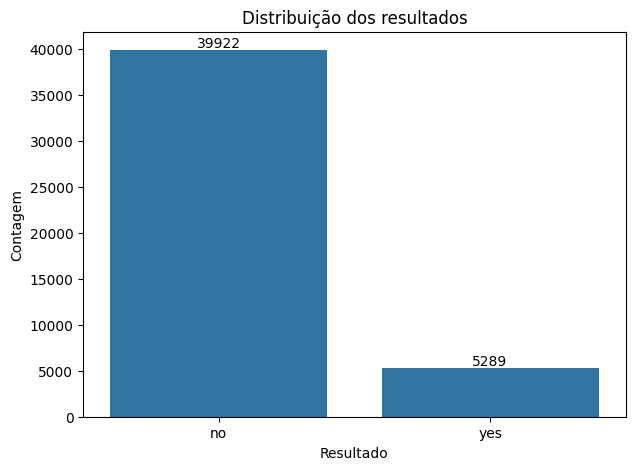

In [188]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
df['result'] = df['result'].fillna('NaN')
axes = sns.countplot(x='result', data=df)
plt.title('Distribuição dos resultados')
plt.xlabel('Resultado')
plt.ylabel('Contagem')
plt.bar_label(axes.containers[0])
plt.show()

O gráfico de barras mostra um desbalanceamento entre as categorias. Enquanto cerca de 5 mil (12%) são registros de casos bem-sucedidos, 40 mil (88%) são registros de casos mal-sucedidos. Na etapa de pré-processamento iremos verificar a melhor forma de diminuir essa diferença.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [189]:
# estatísticas descritivas básicas do dataset
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Análise inicial:**
- **age**: os valores de idade parecem estar dentro de uma distribuição esperada, com valores mínimos e máximos dentro do esperado.
- **balance**: o balanço médio anual apresenta uma amplitude de valores (min: -8019 e max: 102127). Embora, sejam valores significativos, não necessariamente são outliers, indicando que o banco buscou abordar diferentes tipos de clientes.
- **day**: os valores demonstram que são dias do mês e que estão dentro do limite aceitável, entre 1 e 31.
- **duration**: embora represente o tempo em segundos, o valor máximo ser de 4918 (81 minutos) provavelmente indica um outiler.
- **campaign**: não temos a informação de quanto tempo durou a campanha, mas pelas informações descritivas (média, desvio padrão e mediana), o valor máximo de 63 ligações pode representar um outlier.
- **pdays**: dias de folga, desde o último contato. O valor -1 indica que não que o cliente não foi contatado anteriormente. Um ponto de atenção é que pelo menos 75% do conjunto de dados é composto de -1, indicando que a grande maioria dos contatos foram feitos pela primeira vez. Além disso, o valor máximo de 871 é um provável outlier, pois é valor muito discrepante dos demais valores da distribuição.
- **previous**: número de contatos realizados antes dessa campanha. As informações apresentadas demonstram que pelo menos 75% do conjunto de clientes nunca foi contatado em campanhas anteriores. Desse modo, o valor máximo de 275 também pode representar um outlier.

## *Análise das variáveis*
Além das medidas descritivas, é importante analisar a **distribuição dos dados**. Esta análise é crucial, pois permite um melhor entendimento dos dados, revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers).

Dentre os principais gráficos para realizar esta análise destacam-se o **histograma**, **gráfico de barras** e o **boxplot**. O *histograma* é utilizado para avaliar variáveis contínuas, representando a distribuição dos dados, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

O *gráfico de barras*, por sua vez, permite contar a quantidade de observações por variável categórica e realizar análises como comparação, contagem, rankeamento.

Já o *boxplot* é amplamente utilizado quando queremos comparar diferentes distribuições. Ele permite analisar quartis, medianas e outliers por variável.

A seguir traremos a análise de cada uma das variáveis do dataset.

In [330]:
def plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, x_label, target):
  fig, ax = plt.subplots(1,2, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  sns.histplot(data=df, kde=True, binwidth=binwidth, x=variable, hue=target, palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[0])
  ax[0].set_xlabel(x_label)
  ax[0].set_ylabel('Frequência')

  sns.boxplot(x=target, y=variable, data=df, hue=target, palette=['#00ff00', '#ff0000'], hue_order=['yes', 'no'], ax=ax[1])
  ax[1].set_xlabel('Resultado')
  ax[1].set_ylabel(x_label)
  plt.show()

In [331]:
def plot_barh_by_hue_result(figsize, df, variable, label, target):
  fig, ax = plt.subplots(2,1, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  # plot 1
  # Preparação do df
  df_group = df.groupby([variable, target], as_index=False, dropna=False).size()
  df_group['total'] = df_group.groupby(variable, dropna=False)['size'].transform('sum')
  df_pivot = df_group.pivot(index=variable, columns=target, values='size')

  df_pivot['total'] = df_pivot[['yes', 'no']].sum(axis=1)
  df_pivot = df_pivot.sort_values(by="total", ascending=True)
  df_pivot.drop(columns=['total'], inplace=True)

  # plot
  df_pivot.plot(kind='barh', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
  ax[0].set_xlabel('Quantidade')
  ax[0].set_ylabel(label)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[0].text(no/2, i, f"{no}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(no + yes/2, i, f"{yes}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(no+yes+100, i, f"Total: {no+yes}", va='center', ha='left', fontsize=9, color='blue')

  # plot 2
  # Preparação do df
  df_group['percent'] = df_group.groupby(variable, dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
  df_pivot = df_group.pivot(index=variable, columns=target, values='percent')
  df_pivot = df_pivot.sort_values(by="yes", ascending=True)

  # plot
  df_pivot.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
  ax[1].set_xlabel('Percentual')
  ax[1].set_ylabel(label)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[1].text(no/2, i, f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
      ax[1].text(no + yes/2, i, f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
  plt.tight_layout()
  plt.show()

In [332]:
def plot_bar_by_hue_result(figsize, df, variable, label, target):
  fig, ax = plt.subplots(1,2, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  # plot 1
  # Preparação do df
  df_group = df.groupby([variable, target], as_index=False, dropna=False).size()
  df_group['total'] = df_group.groupby(variable, dropna=False)['size'].transform('sum')
  df_pivot = df_group.pivot(index=variable, columns=target, values='size')
  df_pivot['total'] = df_pivot[['yes', 'no']].sum(axis=1)
  df_pivot = df_pivot.sort_values(by="total", ascending=False)
  df_pivot.drop(columns=['total'], inplace=True)

  # plot
  df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
  ax[0].set_xlabel(label)
  ax[0].set_ylabel('Quantidade')
  ax[0].tick_params(axis='x', labelrotation=0)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

  # plot 2
  # Preparação do df
  df_group['percent'] = df_group.groupby(variable, dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
  df_pivot = df_group.pivot(index=variable, columns=target, values='percent')
  df_pivot = df_pivot.sort_values(by="yes", ascending=False)

  # plot
  df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
  ax[1].set_xlabel(label)
  ax[1].set_ylabel('Percentual')
  ax[1].tick_params(axis='x', labelrotation=0)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
      ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
  plt.tight_layout()
  plt.show()
  return df_group

### age (idade)

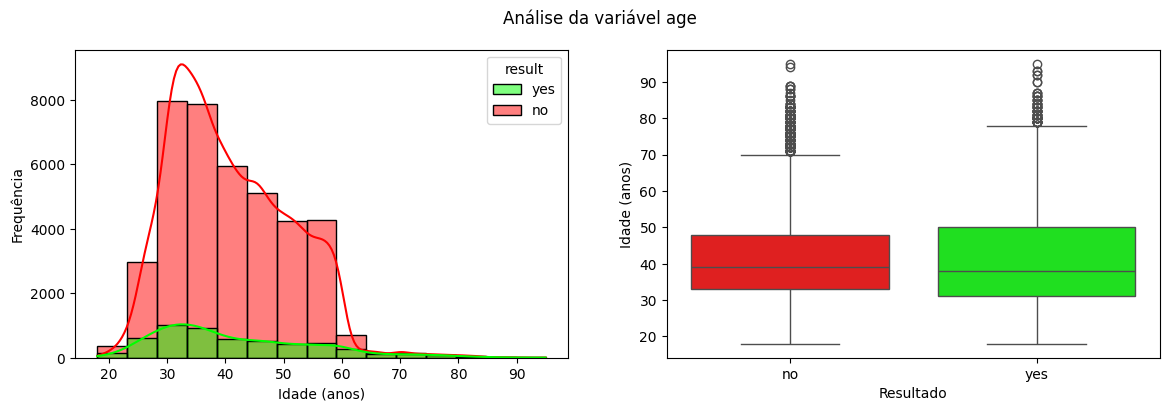

In [333]:
figsize = (14, 4)
variable = 'age'
binwidth = 5
x_label = 'Idade (anos)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, x_label, target)

**Gráfico da esquerda:** histograma dos valores da variável age, com largura dos bins fixada em 5 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável age, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [194]:
print("Valores nulos:", df['age'].isnull().sum())

Valores nulos: 0


Como observado no gráfico de histograma, a distribuição da variável age quase se aproxima de uma distribuição normal, no entanto há uma concentração maior de dados a esquerda do que a direita.

A grande diferença entre casos negativos e casos positivos, acaba dificultando uma análise clara das curvas de comportamento. Após a etapa de pré-processamento, espera-se poder observar melhor a influência dessa variável com relação ao resultado da campanha.

No entanto, a priori, podemos dizer que não há uma distinção tão evidente no formato da curva dos que negaram o contrato, para os que aceitaram o contrato.

Embora o gráfico de boxplot evidencie outliers, observa-se que os valores apresentados estão dentro dos limites consideráveis de tempo de vida humana, ou seja, seriam outliers naturais. Por fim, observa-se que não há valores nulos.

### job (ocupação)

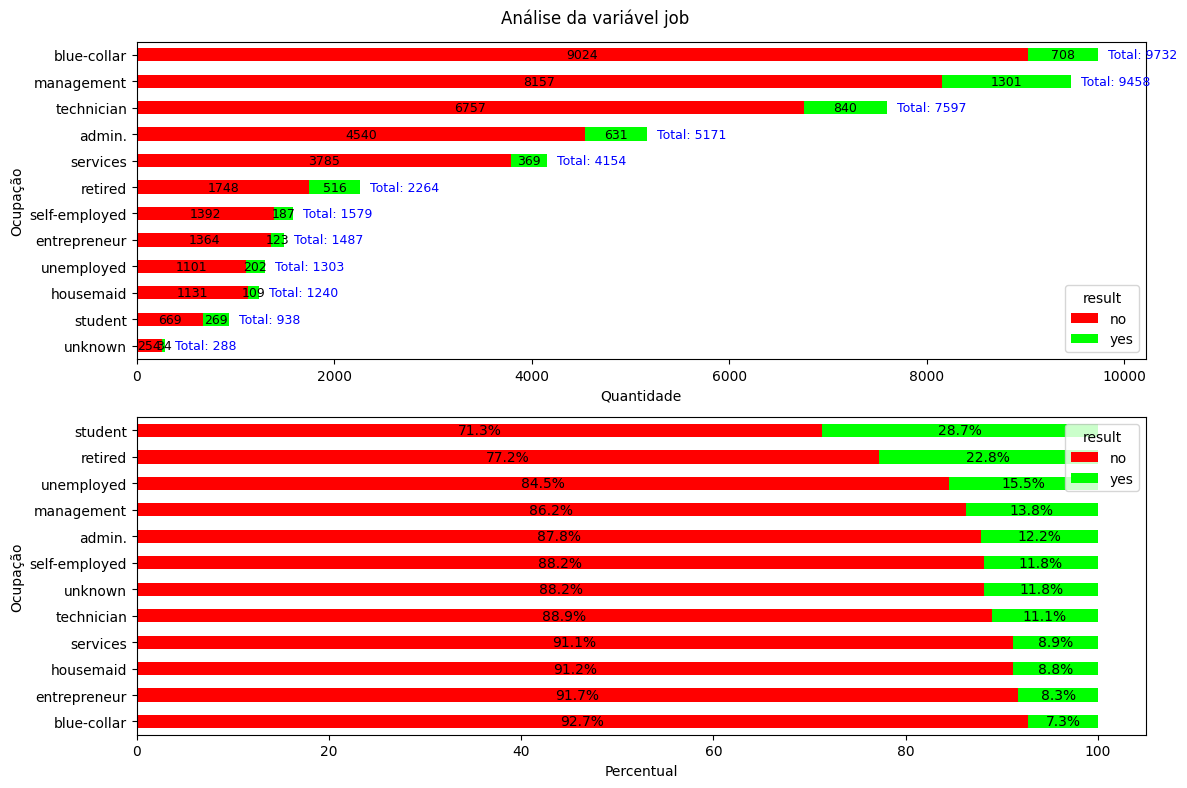

In [334]:
figsize = (12, 8)
variable = 'job'
label = 'Ocupação'
target = 'result'
plot_barh_by_hue_result(figsize, df, variable, label, target)

**Gráfico superior:** gráfico de barras horizontais da quantidade de registros por ocupação, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por ocupação.

**Gráfico inferior:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por ocupação. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [196]:
print("Valores nulos:", df['job'].isnull().sum())

Valores nulos: 0


Novamente, o desbalanceamento do dataset acaba dificultando a análise pura da quantidade de ocorrências por ocupação. Por esse motivo, um segundo gráfico foi apresentado, para analisar o percentual de aceite da campanha por ocupação. O primeiro gráfico está ordenado pelo total de registros por ocupação. Já o segundo, está ordenado por maior percentual de aceitação da campanha.

Com isso, observamos que a ocupação 'blue-collar' foi a mais contatada, seguida pelo 'management' e 'technician'. Mas as ocupações com maior taxa de aceitação foi 'student' (quase 30% de aceitação), 'retired' (22%) e 'unemployed' (15%). Blue-collar, a ocupação mais contatada, foi a de menor taxa de aceitação (7%).

Por fim, observa-se a presença de 288 registros nulos.

### marital (estado civil)

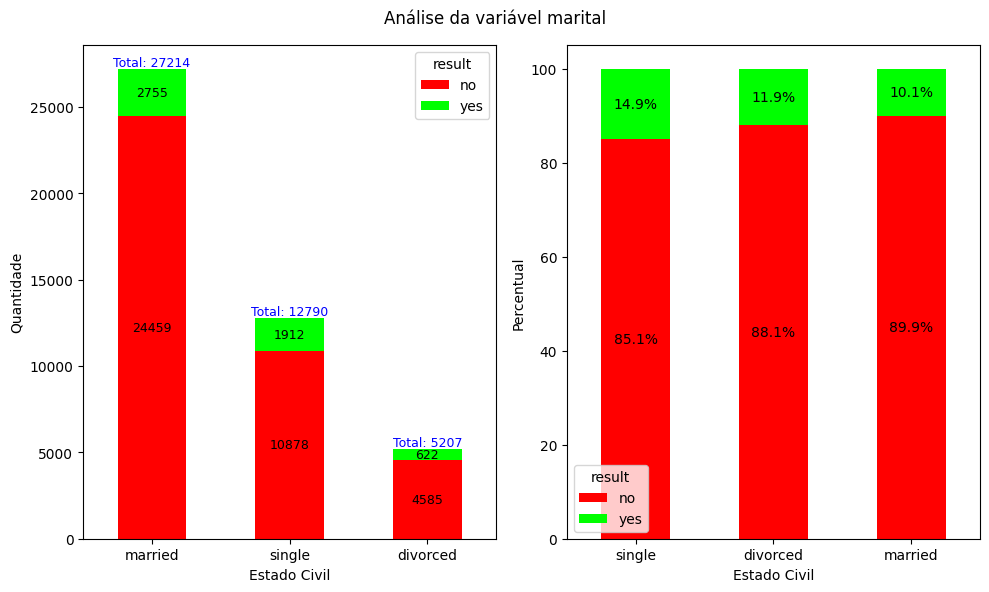

In [335]:
figsize = (10, 6)
variable = 'marital'
label = 'Estado Civil'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por estado civil, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por estado civil.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por estado civil. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [198]:
print("Valores nulos:", df['marital'].isnull().sum())

Valores nulos: 0


Embora haja uma diferença significativa de quantidade de registros de cada estado civil, a diferença entre os valores percentuais não é tão discrepante, indicando que essa variável, possivelmente, não influencia tanto no resultado da campanha. Por fim, observa-se que não há registros nulos.

### education (nível de escolaridade)

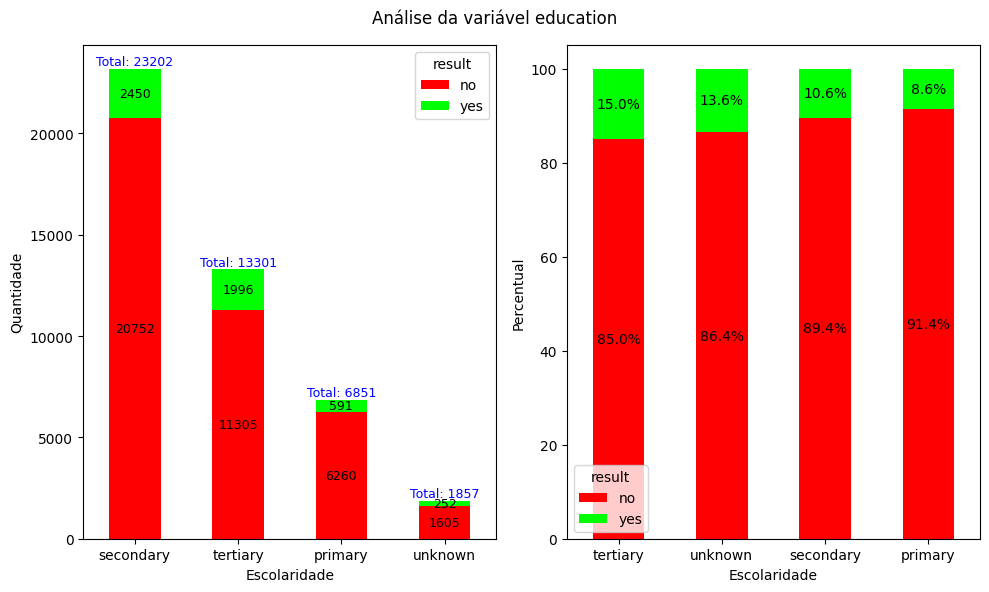

In [336]:
figsize = (10, 6)
variable = 'education'
label = 'Escolaridade'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por nível de escolaridade, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por nível de escolaridade.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por nível de escolaridade. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [200]:
print("Valores nulos:", df['education'].isnull().sum())

Valores nulos: 0


Embora o nível 'secondary' tenha sido o mais contatado, o 'tertiary' foi de maior taxa de aceitação. No entanto, a diferença percentual entre as categorias ainda não seja tão significativa. Por fim, observa-se a presença de 1857 registros nulos.

### default (incumprimento financeiro no passado?)

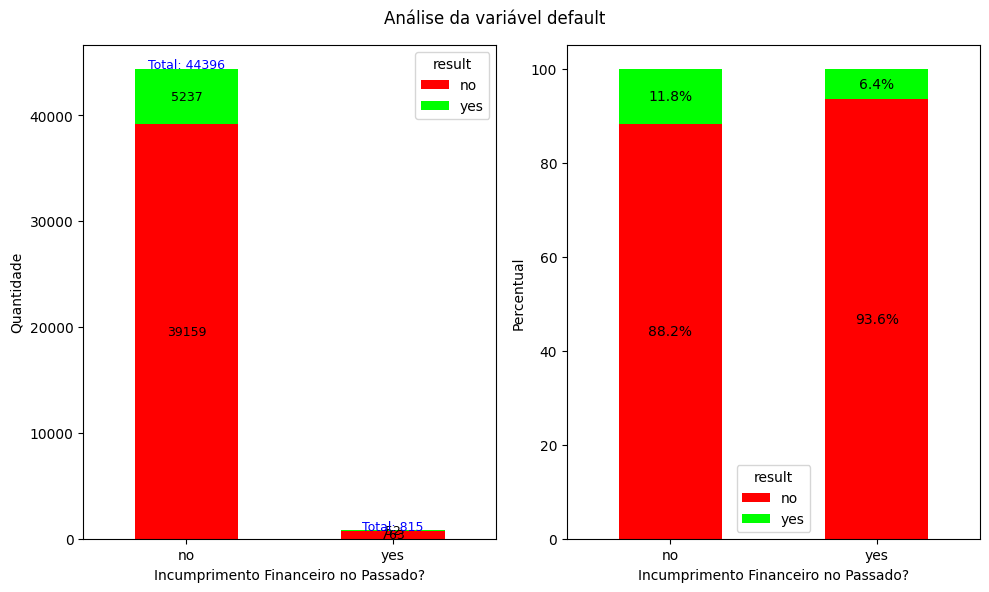

In [337]:
figsize = (10, 6)
variable = 'default'
label = 'Incumprimento Financeiro no Passado?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de incumpimento financeiro, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de incumpimento financeiro.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de incumpimento financeiro. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [202]:
print("Valores nulos:", df['default'].isnull().sum())

Valores nulos: 0


Melhor detalhamento dos valores:

In [203]:
df_group

,default,result,size,total,percent
0,no,no,39159,44396,88.203892
1,no,yes,5237,44396,11.796108
2,yes,no,763,815,93.619632
3,yes,yes,52,815,6.380368


Observamos uma diferença imensa entre a quantidade de pessoas em incumprimento finaceiro (44396) e as que não estão (815). Dessa forma fica difícil avaliar a relevância dessa variável. Em termos percentuais, não há uma diferença significativa. Por fim, observa-se que não há registros nulos.

### balance (saldo médio anual)

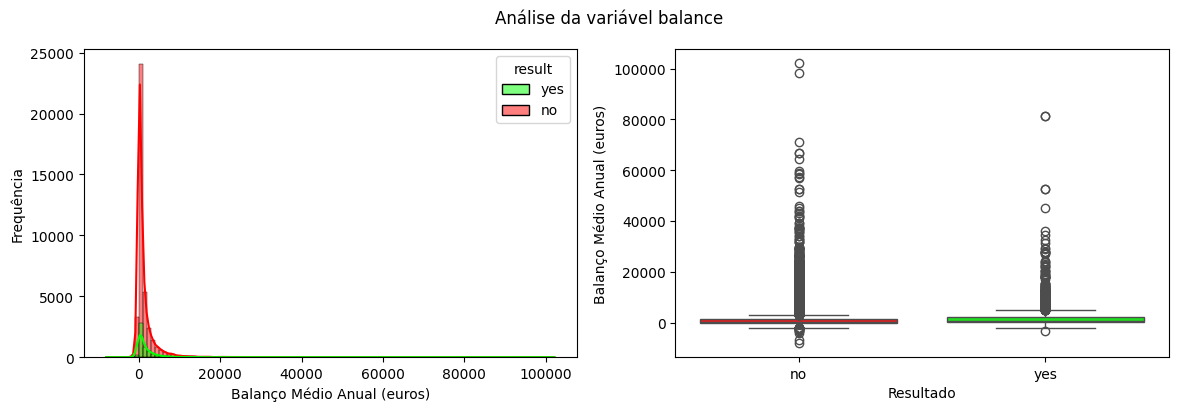

In [338]:
figsize = (14, 4)
variable = 'balance'
binwidth = 1000
label = 'Balanço Médio Anual (euros)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável balance, com largura dos bins fixada em 1000 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável balance, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [205]:
print("Valores nulos:", df['balance'].isnull().sum())

Valores nulos: 0


A variável foi divida em faixa de valores para facilitar a visualização. Vários intervalos foram testados, até chegar no número de 100 bins. A distribuição pode ser considerada assimétrica à direita. Observa-se a presença de outliers, pois uma quantidade ínfima de clientes passa do balanço médio de 20 mil ao ano. Isso pode representar um outlier natural, pois pode haver rendas discrepantes, no entanto precisará ser tratado na etapa de pré-processamento.

A presença desses outliers e o desbalanceamento prejudicaram uma melhor visualização da distribuição. Mas, a priori, o gráfico boxplot não indica uma diferença significativa entre as pessoas que aderiram a campanha. Por fim, observa-se que não há presença de valores nulos.

### housing (possui empréstimo imobiário?)

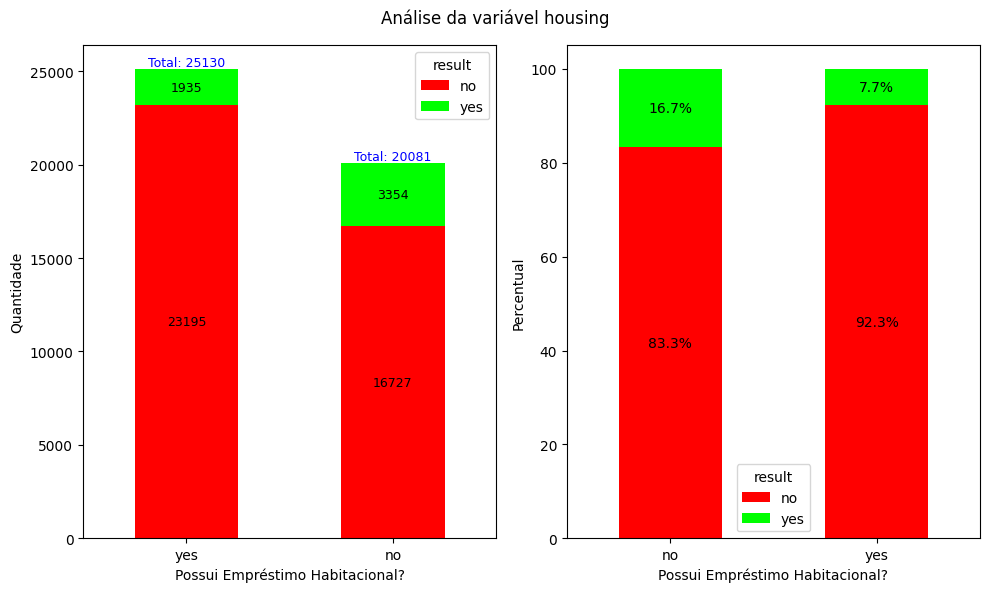

In [339]:
figsize = (10, 6)
variable = 'housing'
label = 'Possui Empréstimo Habitacional?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de empréstimo habitacional, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de empréstimo habitacional.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de empréstimo habitacional. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [207]:
print("Valores nulos:", df['housing'].isnull().sum())

Valores nulos: 0


Esta variável possui um desbalanceamento menos expressivo. Foram contactados cerca de 25 mil clientes que possuiam empréstimo imobiliário, e cerca de 20 mil que não possuiam. Embora a diferença percentual entre as categorias não seja tão significativa, a taxa de adesão à campanha foi maior entre os que não possuiam empréstimo imobiliário. Por fim, observa-se que não há presença de valores nulos.

### loan (possui empréstimo pessoal?)

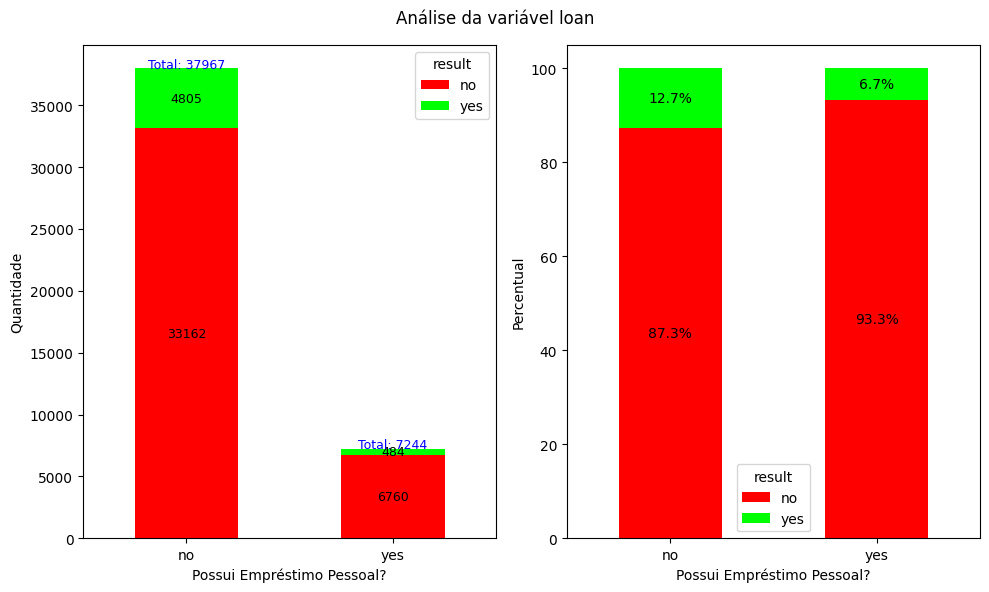

In [340]:
figsize = (10, 6)
variable = 'loan'
label = 'Possui Empréstimo Pessoal?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de empréstimo pessoal, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de empréstimo pessoal.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de empréstimo pessoal. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [209]:
print("Valores nulos:", df['loan'].isnull().sum())

Valores nulos: 0


Há uma quantidade significativa maior de clientes sem empréstimo pessoal, do que os com  empréstimo pessoal. Esse desbalanceamento prejudica a análise. Percentualmente, observa-se uma adesão maior entre os que não possuem empréstimo, do que os que possuem. Por fim, não há presença de valores nulos.

### contact (tipo de contato)

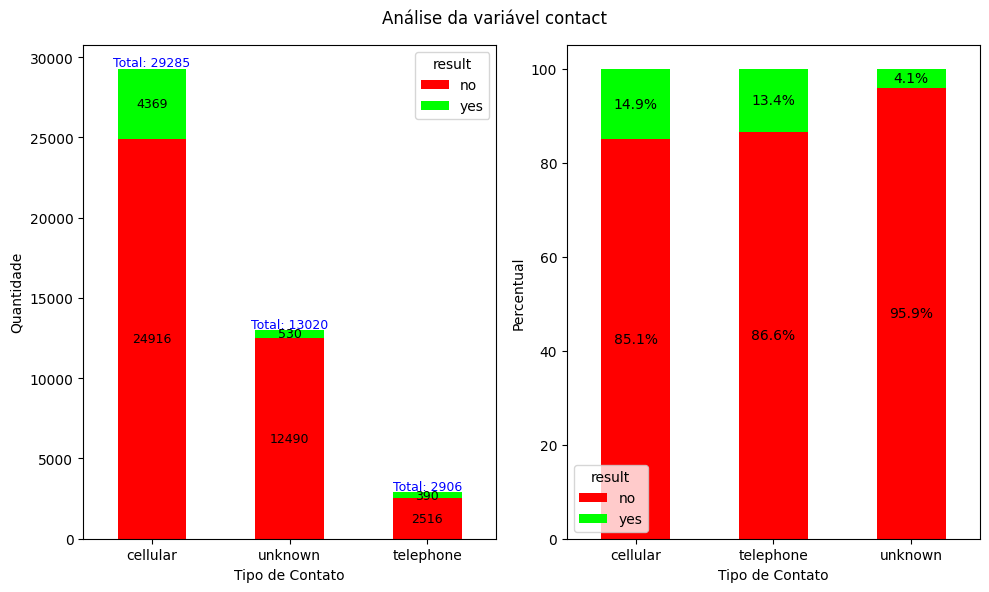

In [341]:
figsize = (10, 6)
variable = 'contact'
label = 'Tipo de Contato'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por tipo de contato, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por tipo de contato.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por tipo de contato. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [211]:
print("Valores nulos:", df['contact'].isnull().sum())

Valores nulos: 0


Há uma quantidade significativa maior de clientes contactados via celular (29096) sem empréstimo pessoal, do que os com empréstimo pessoal. Esse desbalanceamento prejudica a análise. Apesar disso, percentualmente, observa-se uma adesão maior entre os que não possuem empréstimo, do que os que possuem. Por fim, observa-se que há 13020 registros sem a informação do tipo de contato realizado.

### day (último dia de contato)

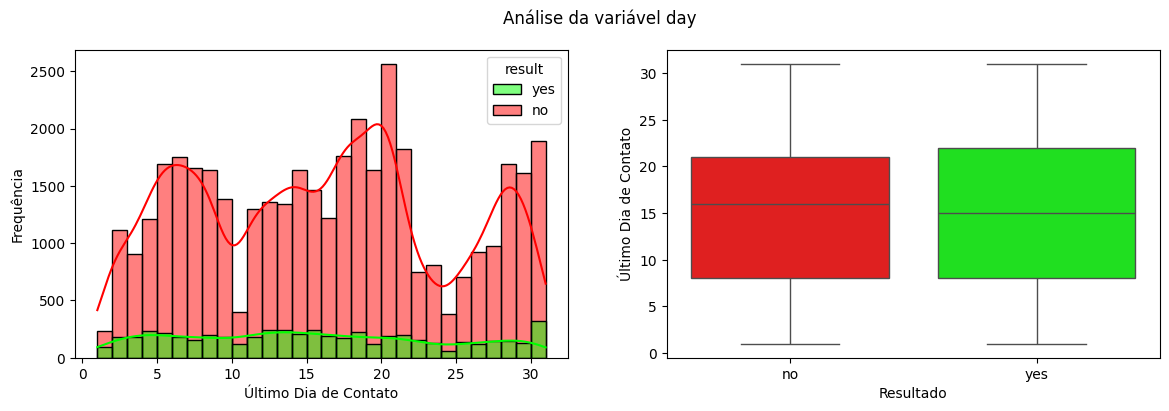

In [342]:
figsize = (14, 4)
variable = 'day'
binwidth = 1
label = 'Último Dia de Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável day, com largura dos bins fixada em 1 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável day, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [213]:
print("Valores nulos:", df['day'].isnull().sum())

Valores nulos: 0


A distribuição apresentada está mais próxima de uma distribuição multimodal.

Do mesmo modo que a variável anterior, a diferença no número de registros de cada classe, acaba dificultando uma análise mais acertiva.

Os valores apresentados estão dentro dos limites de dias do mês. Em geral, não há uma distinção entre o dia de contato e o resultado da campanha. Um destaque especial para os dias 1, 11 e 25, dias com menor quantidade de contatos e para o dia 21, dia com maior quantidade de contatos.

Se a variável trouxesse a informação de qual dia da semana foi realizado o contato (seg, ter, ..., sab) seria uma informação ainda mais relevante para a análise. Podemos utilizar essa informação para dividir o mês em semanas e analisar se houve alguma semana com maior ou menor destaque.

Por fim, observa-se que não há presença de valores nulos.

### month (mês do último contato)

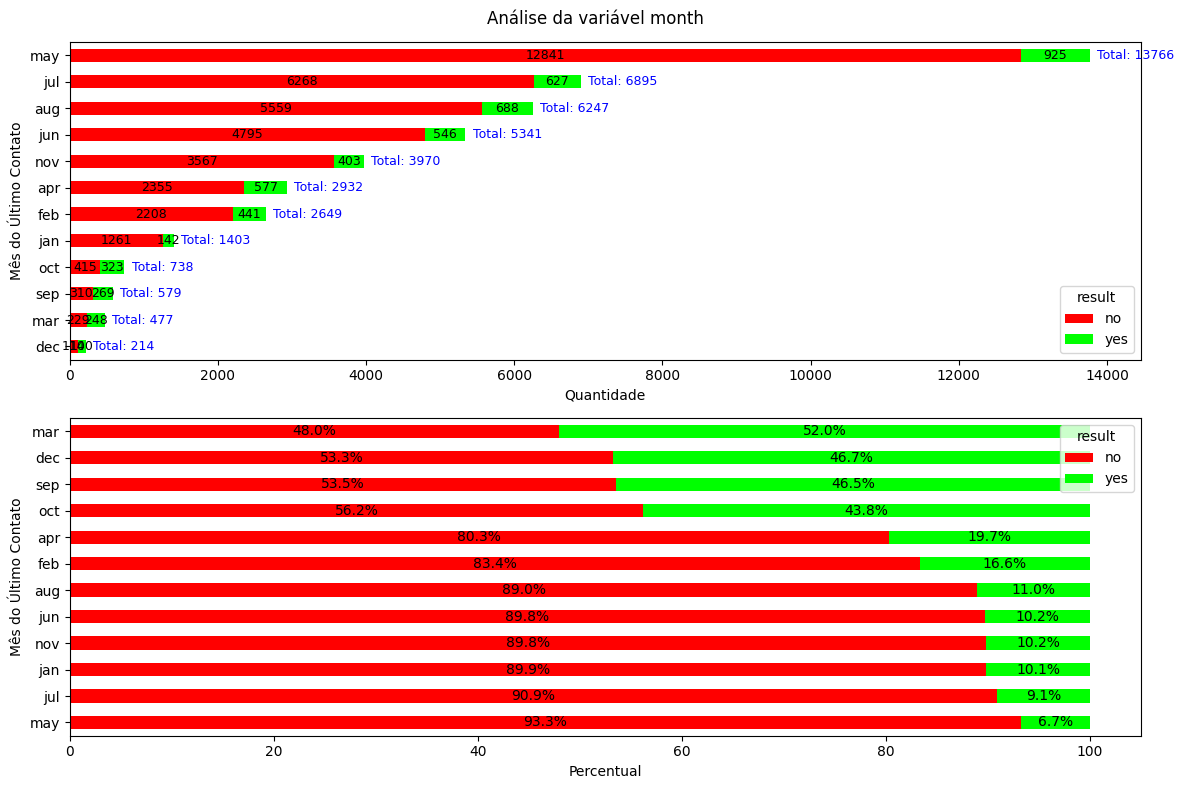

In [343]:
figsize = (12, 8)
variable = 'month'
label = 'Mês do Último Contato'
target = 'result'
plot_barh_by_hue_result(figsize, df, variable, label, target)

**Gráfico superior:** gráfico de barras horizontais da quantidade de registros por mês do último contato, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por mês do último contato.

**Gráfico inferior:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por mês do último contato. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [215]:
print("Valores nulos:", df['month'].isnull().sum())

Valores nulos: 0


O mês de maio foi o mês com a maior quantidade de contatos realizados. No entato, em termos percentuais foi o mês com a menor taxa de aceitação da campanha.

A diferença entre o 1º e o 2º mês de maior contato é extremamente grande. O segundo mês possui praticamente a metade do total de contatos realizados no primeiro mês. Isso é mais um indicativo de desbalanceamento do dataset.

Curiosamente os mêses com menor atividade foram os meses com maior percentual de conversão (março, dezembor, setembro e outubro).

Por fim, não há presença de registros nulos.

 ### duration (duração da ligação)

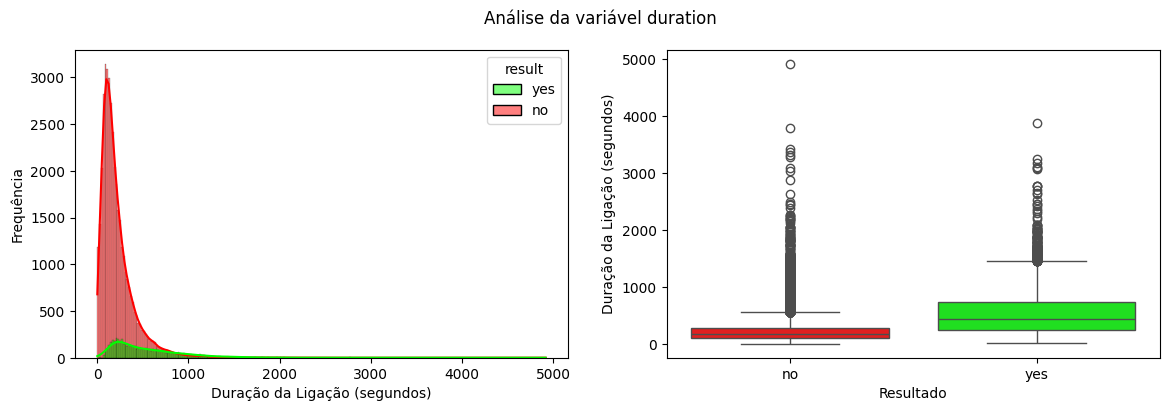

In [344]:
figsize = (14, 4)
variable = 'duration'
binwidth = 20
label = 'Duração da Ligação (segundos)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável duration, com largura dos bins fixada em 10 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável duration, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [217]:
print("Valores nulos:", df['duration'].isnull().sum())

Valores nulos: 0


O histograma indica uma distribuição assimétrica à direita, com presença de possíveis outliers em chamadas superiores a 80 minutos. Esses valores extremos, somados ao desbalanceamento do dataset, dificultam uma análise mais robusta dessa variável.

Como descrito na documentação, a duração da chamada influencia diretamente o resultado da campanha: contatos nulos ou muito curtos tendem a gerar insucesso, enquanto chamadas mais longas estão associadas a maior taxa de sucesso, como evidenciado no boxplot.

Dada a forte correlação com a variável alvo, a duração da chamada não será utilizada nesta tarefa de classificação.

Por fim, não foram encontrados valores nulos.

### campaign (número de contatos realizados na campanha)

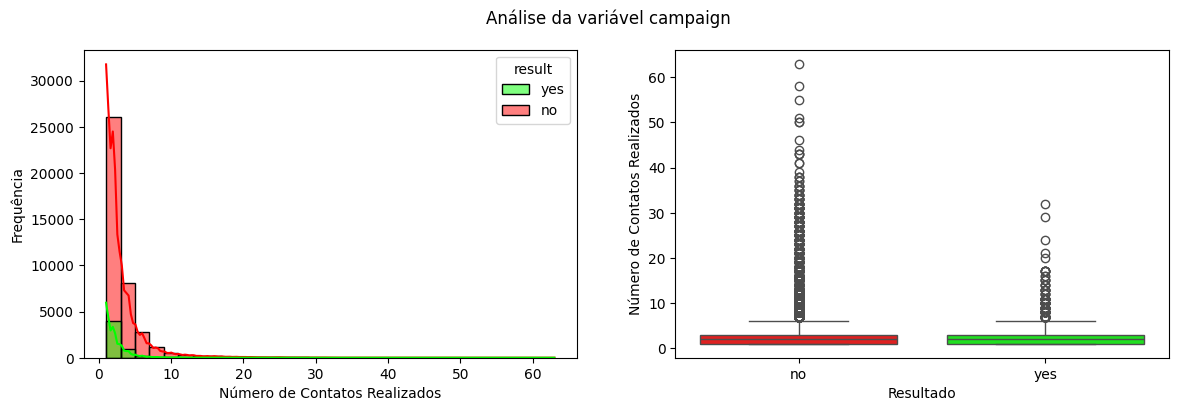

In [345]:
figsize = (14, 4)
variable = 'campaign'
binwidth = 2
label = 'Número de Contatos Realizados'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável campaign, com largura dos bins fixada em 2 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável campaign, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Verificação da presença de valores nulos:

In [219]:
print("Valores nulos:", df['campaign'].isnull().sum())

Valores nulos: 0


A variável foi discretizada em faixas de largura 2 para facilitar a visualização. Observa-se que a maioria dos clientes recebeu entre 2 e 5 contatos, enquanto um número ínfimo chegou a ser contactado até 63 vezes, caracterizando outliers que dificultam a interpretação da distribuição.

O boxplot indica que a quantidade de contatos não exerce influência significativa sobre o resultado da campanha, embora haja maior concentração de outliers associados a insucessos.

Por fim, não foram identificados valores nulos nesta variável, o que reforça a consistência dos dados.

### pdays (número de dias desde o último contato)

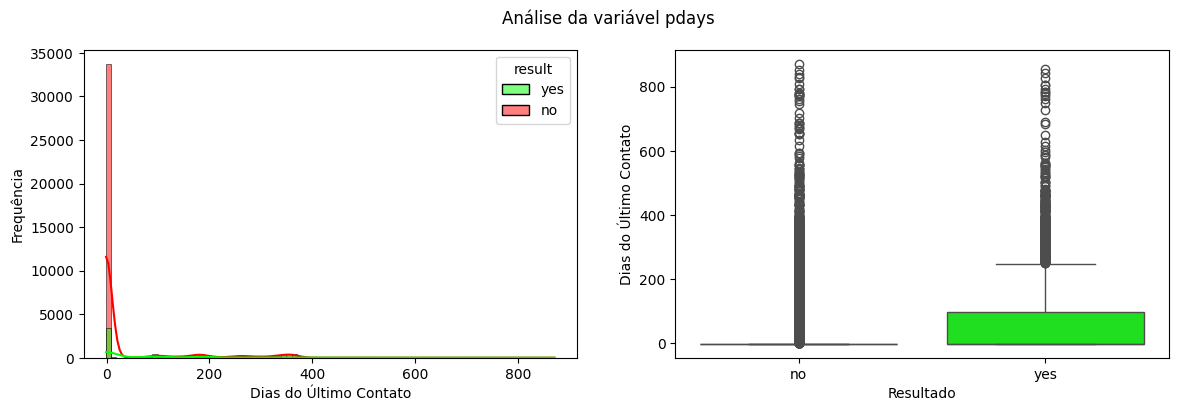

In [346]:
figsize = (14, 4)
variable = 'pdays'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável pdays, com largura dos bins fixada em 10 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável pdays, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Ao tentar analisar os dados brutos, observamos um grande desbalanceamento na primeira faixa de valore (de 0 a 10 dias). Vamos agrupar os valores da variável pdays e observar o começo e o final da distribuição.

In [221]:
df.groupby(['pdays', 'result'], as_index=False).size().sort_values(by='pdays').head()

,pdays,result,size
0,-1,no,33570
1,-1,yes,3384
2,1,no,9
3,1,yes,6
4,2,no,35


Observa-se que a grande maioria dos clientes foram contactados pela primeira vez (36.954, cerca de 81%).

In [222]:
df.groupby(['pdays', 'result'], as_index=False).size().sort_values(by='pdays').tail()

,pdays,result,size
909,838,no,1
910,842,yes,1
911,850,no,1
912,854,yes,1
913,871,no,1


Além disso, dentre os que foram contatados mais de uma vez, alguns apresentam um espaço de tempo muito longo, chegando até 871 dias (mais de dois anos e meio).

Como há uma grande diferença entre os clientes que foram contactados pela primeira vez (pdays = -1) e os que foram contactados mais de uma vez (pdays > 0), iremos analisar os registros separadamente.

**Analisando os contactados mais de uma vez (pdays > 0):**

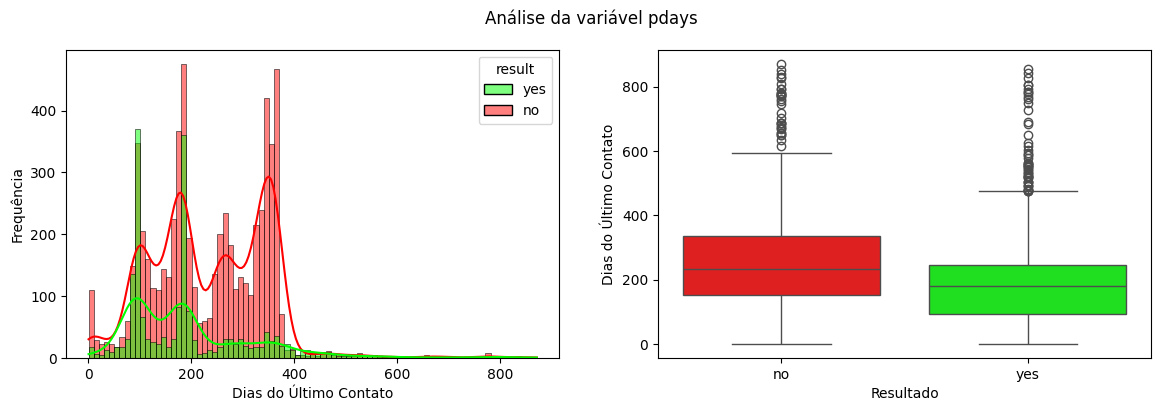

In [347]:
figsize = (14, 4)
variable = 'pdays'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[df.pdays > 0], variable, binwidth, label, target)

No histograma (gráfico da esquerda), observa-se uma distribuição multimodal. Além disso, nota-se que até 200 dias de folga, o comportamento das linhas do resultado são semelhantes, e em alguns momentos, o resultado positivo chega a superar o resultado negativo. Após 200 dias, a linha de sucesso praticamente não cresce mais, e as tentativas de contato, quase sempre resultaram em fracasso.

O boxplot (gráfico da direita) demonstra um pouco esse comportamento, com a maioria dos casos de sucesso estarem antes dos 200 dias. Como visto anteriormente, há alguns registros extremos (com mais de 800 dias de contato) que devem ser analisados e tratados.

**Analisando os contactados apenas uma vez (pdays = -1):**

Para esta análise, preferimos dividir o dataframe em duas partes: um contato e múltiplos contatos. Uma nova coluna booleana, chamada 'multiplos_contatos', foi criada para realizar a análise. Essa coluna recebe o valor True, caso o número de dias de folga (pdays) seja maior que zero, indicando que houve mais de um contato, e recebe o valor falso, caso pdays seja menor que 0.

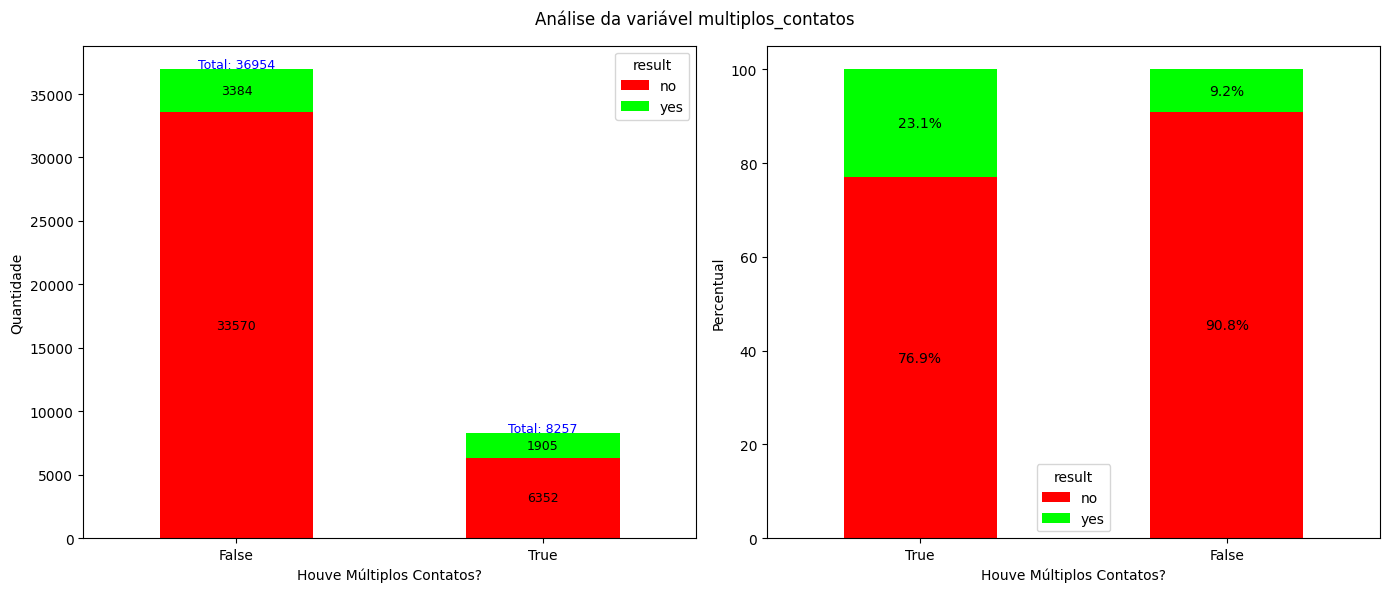

In [348]:
df['multiplos_contatos'] = df['pdays'] > 0
figsize = (14, 6)
variable = 'multiplos_contatos'
label = 'Houve Múltiplos Contatos?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por situação de múltiplos contatos, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por situação de múltiplos contatos.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por situação de múltiplos contatos. O gráfico está ordenado da maior taxa de aceitação para a menor.

Embora haja uma diferença significativa entre registros que foram contactados mais de uma vez (8257) e os que não foram (36954). Observa-se que o percentual de aceitação foi maior entre os que tiveram múltiplos contatos.

Uma proposta de tratamento desta variável, seria discretizar as informações em faixas de valores, como "primeiro contato", "até 10 dias de folga", "até 20 dias de folga", etc.

Verificação da presença de valores nulos:

In [225]:
print("Valores nulos:", df['pdays'].isnull().sum())

Valores nulos: 0


Não há registros nulos.

### previous (número de contatos realizados antes desta campanha)

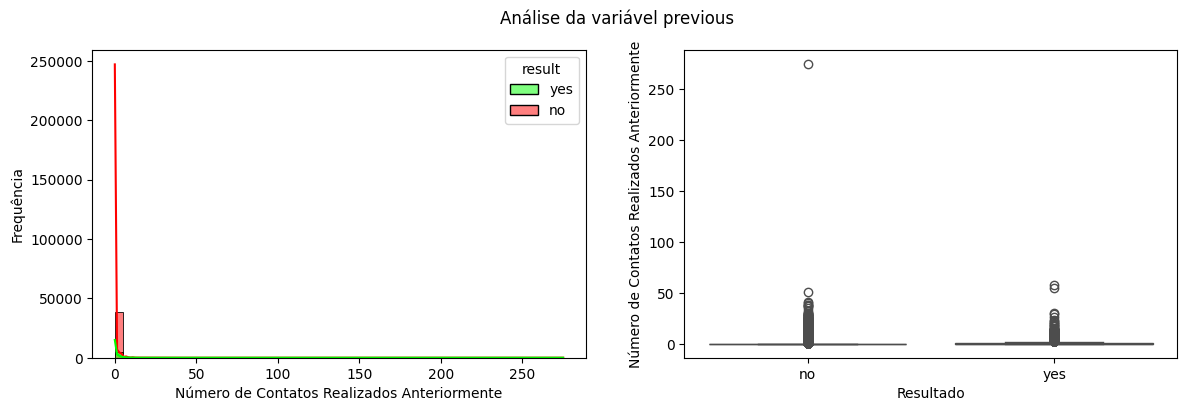

In [349]:
figsize = (14, 4)
variable = 'previous'
binwidth = 5
label = 'Número de Contatos Realizados Anteriormente'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

**Gráfico da esquerda:** histograma dos valores da variável previous, com largura dos bins fixada em 10 e distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

**Gráfico da direita:** boxplot dos valores da variável previous, com distinção entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha).

Ao tentar analisar os dados brutos, observamos um grande desbalanceamento na primeira faixa de valore (de 0 a 5 contatos). Vamos agrupar os valores da variável previous e observar o começo e o final da distribuição.

Análise inicial dos valores desta variável:

In [227]:
df.groupby(['previous', 'result'], as_index=False).size().sort_values(by='previous').head()

,previous,result,size
0,0,no,33570
1,0,yes,3384
2,1,no,2189
3,1,yes,583
4,2,no,1650


Há uma grande quantidade de clientes que foram contactados apenas nesta campanha (36.954, cerca de 81%). Coincidentemente, esse valor é igual ao valor de clientes que foram contactados uma única vez na campanha (variável anterior - pdays).

In [228]:
df.groupby(['previous', 'result'], as_index=False).size().sort_values(by='previous').tail()

,previous,result,size
61,41,no,1
62,51,no,1
63,55,yes,1
64,58,yes,1
65,275,no,1


Além disso, dentre os que já foram contatados em campanhas anteriores, um registro se destaca por ter sido contactado 275 vezes, enquanto que o restante dos contatos  .

Da mesma forma que a variável pdays, a grande quantidade de registros de clientes que nunca foram contactados em campanhas anteriores prejudica a análise mais adequada da distribuição dos registros. Desse modo, novamente, iremos dividir a análise entre os que foram contactados em campanhas anteriores e os que foram contactados apenas na campanha atual.

Embora seja parecida com a variável anterior, aparenta ter menos valores extremos.

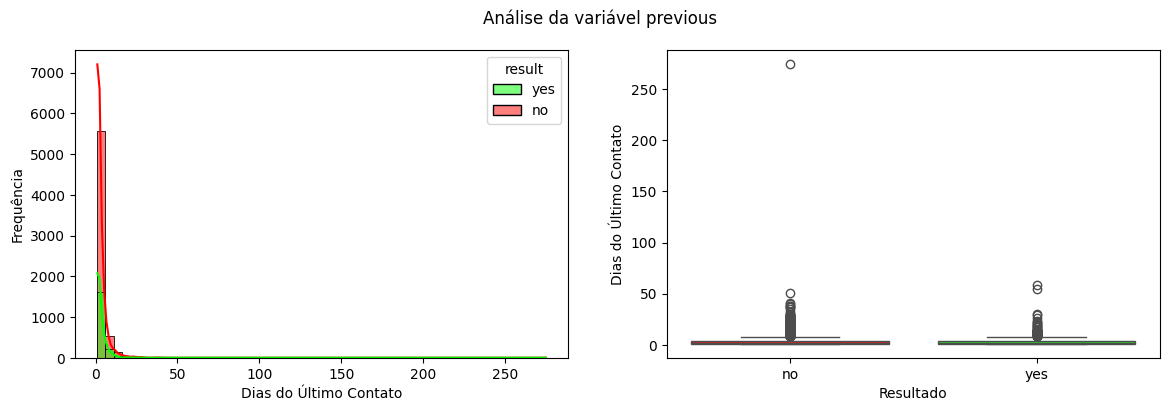

In [350]:
figsize = (14, 4)

variable = 'previous'
binwidth = 5
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[(df.previous > 0)], variable, binwidth, label, target)

Após a remoção dos registros dos que nunca foram contactados em campanhas anteriores, a distibuição ainda permanece assimétrica a direita. Devido a presença de alguns valores extremos, ainda não é possível visualizar tão bem a distribuição. Após o tratamento de outliers poderemos analisar melhor o resultado.

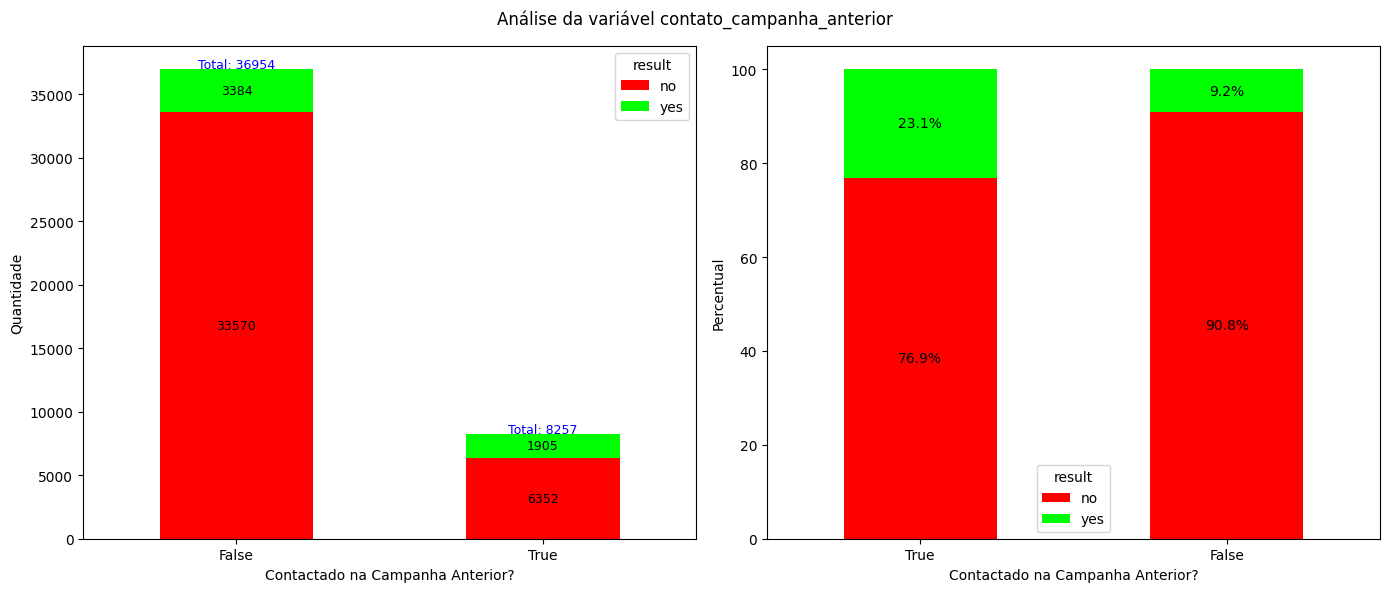

In [351]:
df['contato_campanha_anterior'] = df['previous'] > 0
figsize = (14, 6)
variable = 'contato_campanha_anterior'
label = 'Contactado na Campanha Anterior?'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)


Curiosamente, até o percentual de aceitação entre os que foram contactados na campanha anterior e os que não foram, foi igual ao resultado da variável anterior (pdays - dias de folga). Mas como mostramos no gráfico anterior, elas não são iguais, pois possuem distribuições diferentes. Assim, observando os gráficos acima, embora a diferença entre os que foram contactados em campanhas anteriores e os que não foram seja grande, podemos considerar, olhando para os percentuais apresentados, que os clientes que foram contactados em campanhas  anteriores, aderiram melhor a campanha.

Verificação da presença de valores nulos:

In [231]:
print("Valores nulos:", df['previous'].isnull().sum())

Valores nulos: 0


Não há registros nulos.

### poutcome (resultado da campanha anterior)

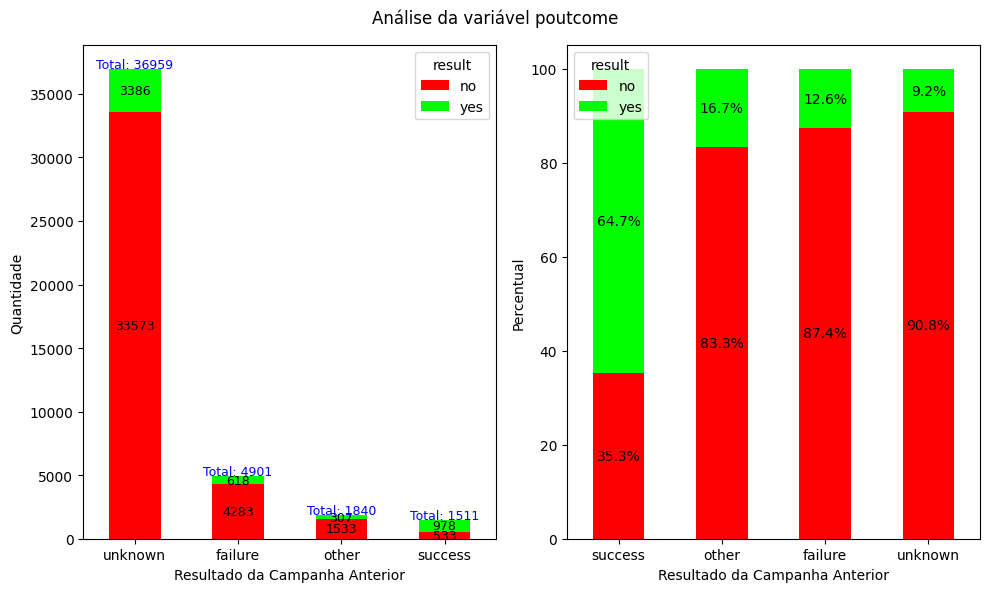

In [352]:
figsize = (10, 6)
variable = 'poutcome'
label = 'Resultado da Campanha Anterior'
target = 'result'
df_group = plot_bar_by_hue_result(figsize, df, variable, label, target)

**Gráfico da esquerda:** gráfico de barras horizontais da quantidade de registros por resultado da campanha anterior, ordenadas da maior quantidade para a menor quantidade, além de distinguir entre os casos de sucesso (cor verde) ou falha da campanha (cor vermelha) por resultado da campanha anterior.

**Gráfico da direita:** gráfico de barras horizontais da distribuição percentual do resultado da campanha, por resultado da campanha anterior. O gráfico está ordenado da maior taxa de aceitação para a menor.

Verificação da presença de valores nulos:

In [233]:
print("Valores nulos:", df['poutcome'].isnull().sum())

Valores nulos: 0


Esta variável possui o maior déficit de informações: 36959 registros nulos. No entanto, como visto na variável anterior (previous), 36954 registros não foram contatados em campanhas anteriores, o que pode responder o motivo dessa variável possuir tantos valores nulos. Na etapa de pré-processamento, poderemos analisar se isso é verdadeiro, e criar uma nova categoria para esses registros, como "N/A", ou considerar utilizar o valor 'other'.

Analisando apenas o resultado dos valores não nulo ('failure', 'other' e 'sucess') podemos perceber duas coisas relevantes:
- Dentre as pessoas que aderiram à campanha anterior (sucess), a quantidade pessoas que também aderiram a campanha atual foi maior do que os que não aderiram;
- Dentre as pessoas que recusaram a campanha anterior, a grande maioria também recusou a campanha atual.

Isso mostra que o produto pode ter sido bem apreciado por quem experimentou, mas dificilmente os clientes são convencidos de que é um bom produto.

Por fim, observa-se que não há presença de valores nulos.

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

Para analisar a correlação entre as variáveis, iremos adicionar uma nova coluna ao dataframe, convertendo a variável alvo 'result' em uma variável efetivamente binária. Ou seja, o valor 'yes' se tornará 1 e o valor 'no' se tornará 0.

In [234]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df['result_num'] = df['result'].map({'yes': 1, 'no': 0})
variaveis_numericas = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous',
    'result_num'
]
df[variaveis_numericas].corr()


Matriz de Correlação:


,age,balance,day,duration,campaign,pdays,previous,result_num
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.025155
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674,0.052838
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.028348
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.394521
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000,0.093236
result_num,0.025155,0.052838,-0.028348,0.394521,-0.073172,0.103621,0.093236,1.000000


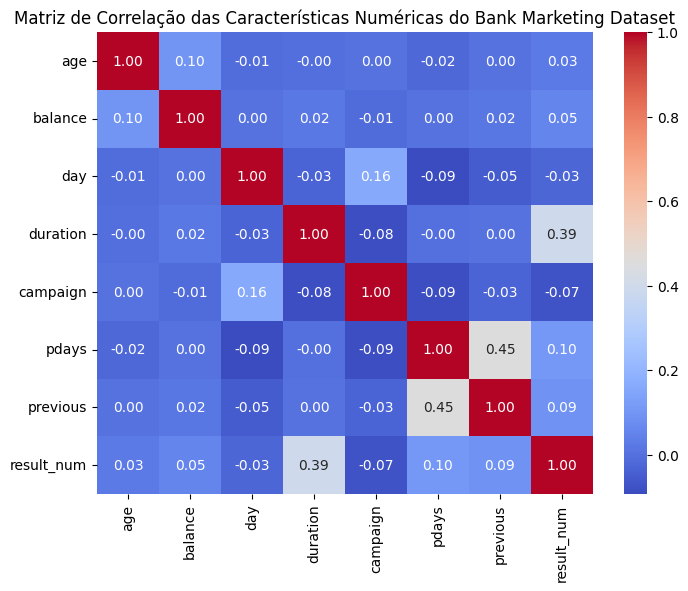

In [235]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Bank Marketing Dataset')
plt.show()

Observando o mapa de calor, praticamente todas as variáveis são pouco correlacionadas. As que tem um grau maior de correlação são 'previous' e 'pdays', e 'duration' e 'result_num'.

Conforme indicado na própria documentação do dataset, a variável 'duration' possui forte relação com o resultado da campanha, já que uma duração igual a 0 ou próximo disso, dificilmente gera um resultado positivo.

Já as variáveis 'pdays' (dias do último contato) e 'previous' (contatos realizados na última campanha) possuem uma correlação mais alta, devido ao grande número de registros que foram contactados apenas uma vez na campanha atual e que nunca foram contactados em campanhas anteriores. A variável 'pdays' representa esses registros como -1, e a variável 'previous' representa esses registros como 0. Mas além dessa semelhança, essas variáveis não são correlacionadas.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Descarte de colunas

Como indicado na análise da variável duration, ela não será utilizada no treinamento do modelo, por tanto iremos remover do dataset.

Além disso, iremos descartar as colunas 'multiplos_contatos','contato_campanha_anterior' e 'result_num' que foram criadas apenas para análises temporárias dos dados.

In [236]:
df_droped = df.drop(columns=['duration', 'multiplos_contatos', 'contato_campanha_anterior', 'result_num'])

## Renomear colunas

In [237]:
df_droped.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous',
       'poutcome', 'result'],
      dtype='object')

Para facilitar o entendimento do tipo de dado armazenado da coluna, iremos renomear algumas colunas.

In [238]:
df_renamed = df_droped.rename(columns={
    'age': 'client_age',
    'job': 'client_job',
    'marital': 'client_marital_status',
    'education': 'client_education_level',
    'default': 'client_financial_default',
    'balance': 'client_average_annual_balance',
    'housing': 'client_housing_loan',
    'loan': 'client_personal_loan',
    'contact': 'contact_type',
    'day': 'contact_day_of_month',
    'month': 'contact_month',
    'campaign': 'number_contacts_campaign',
    'pdays': 'days_last_contact',
    'previous': 'number_contacts_previous_campaign',
    'poutcome': 'result_previous_campaign',
    'result': 'result_campaign'
})

## Tratamento de Valores Nulos

Como vimos anteriormente, algumas das variáveis do dataset possuem colunas nulas. Vejamos:

In [239]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Bank Marketing:")
df_renamed.isnull().sum()

Valores nulos no dataset Bank Marketing:


,0
client_age,0
client_job,0
client_marital_status,0
client_education_level,0
client_financial_default,0
client_average_annual_balance,0
client_housing_loan,0
client_personal_loan,0
contact_type,0
contact_day_of_month,0


Como observado, as colunas client_job, client_education_level, contact_type e result_previous_campaign possuem valores nulos. Como as 4 variáveis são variáveis categóricas, podemos criar uma nova categoria, chamada "unknown", para indicar esses valores desconhecidos.

No caso da variável result_previous_campaign, conforme observado na análise exploratória, o número de valores nulos (36959) é muito semelhante ao de clientes que não foram contactados em campanhas anteriores (36954). Ou seja, se o cliente não foi contatado em campanhas anteriores, não pode haver o resultado da campanha anterior, então, nesse caso, a categoria aplicada deverás ser "N/A" (não se aplica).

In [240]:
df_not_nulls = df_renamed.copy()
df_not_nulls['client_job'] = df_not_nulls['client_job'].fillna('unknown')
df_not_nulls['client_education_level'] = df_not_nulls['client_education_level'].fillna('unknown')
df_not_nulls['contact_type'] = df_not_nulls['contact_type'].fillna('unknown')

Para a coluna result_previous_campaign, iremos preencher com 'N/A', os clientes que não foram contactados em campanhas anteriores e com 'other' para os clientes que foram contactados, mas que não sabemos o resultado. Lembranco que a categoria 'other' já está presente no dataset original.

In [242]:
df_not_nulls.loc[(
  df_not_nulls.result_previous_campaign.isna())
  & (df_not_nulls.number_contacts_previous_campaign == 0),
  'result_previous_campaign'] = 'N/A'
df_not_nulls.loc[(
  df_not_nulls.result_previous_campaign.isna())
  & (df_not_nulls.number_contacts_previous_campaign > 0),
  'result_previous_campaign'] = 'other'

Verificando a presença de valores nulos novamente:

In [243]:
df_not_nulls.isnull().sum()

,0
client_age,0
client_job,0
client_marital_status,0
client_education_level,0
client_financial_default,0
client_average_annual_balance,0
client_housing_loan,0
client_personal_loan,0
contact_type,0
contact_day_of_month,0


Com isso, todos os valores nulos foram tratados.

## Tratamento de outliers

A presença de valores extremos pode representar erros ou até mesmo um comportamento natural dos dados. A seguir, iremos analisar as variáveis os valores extremos das variáveis numéricas do dataset.

In [518]:
df_without_outliers = df_not_nulls.copy()

Como todas as distribuições das variáveis numéricas analisadas não seguem a distribuição normal, iremos avaliar a presença de outliers a partir do intervalo interquartil (IQR).

Cálculo pelo IQR:

In [519]:
def recuperar_outliers_IQR(df, variavel):
  Q1 = df[variavel].quantile(0.25)
  Q3 = df[variavel].quantile(0.75)
  IQR = Q3 - Q1

  # Definindo limites
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print("Limite inferior:", lower_bound)
  print("Limite superior:", upper_bound)

  # Recuperando registros outliers
  return df[(df[variavel] < lower_bound) | (df[variavel] > upper_bound)]


### Análise dos outliers por variável


In [520]:
for variavel in ['client_age', 'client_average_annual_balance', 'number_contacts_campaign', 'days_last_contact', 'number_contacts_previous_campaign']:
  print(f"Análise dos outliers da variável {variavel} pelo IQR:")
  outliers_IQR = recuperar_outliers_IQR(df_without_outliers, variavel)
  print("Total de registros considerados outliers:", outliers_IQR[variavel].count())
  print("Menor valor encontrado: ", outliers_IQR[variavel].min())
  print("Maior valor encontrado:", outliers_IQR[variavel].max())
  print("-"*20)

Análise dos outliers da variável client_age pelo IQR:
Limite inferior: 10.5
Limite superior: 70.5
Total de registros considerados outliers: 487
Menor valor encontrado:  71
Maior valor encontrado: 95
--------------------
Análise dos outliers da variável client_average_annual_balance pelo IQR:
Limite inferior: -1962.0
Limite superior: 3462.0
Total de registros considerados outliers: 4729
Menor valor encontrado:  -8019
Maior valor encontrado: 102127
--------------------
Análise dos outliers da variável number_contacts_campaign pelo IQR:
Limite inferior: -2.0
Limite superior: 6.0
Total de registros considerados outliers: 3064
Menor valor encontrado:  7
Maior valor encontrado: 63
--------------------
Análise dos outliers da variável days_last_contact pelo IQR:
Limite inferior: -1.0
Limite superior: -1.0
Total de registros considerados outliers: 8257
Menor valor encontrado:  1
Maior valor encontrado: 871
--------------------
Análise dos outliers da variável number_contacts_previous_campaign 

Para a variável client_age, observamos que os valores apontados como outliers não se tratam de erros, pois estão dentro de um limite aceitável de tempo de vida humana. Assim, não iremos aplicar nenhum tratamento em cima dessa variável.

Para as demais variável, observamos uma quantidade significativa de registros apontados como outliers e precisará ser feita uma análise mais detalhada desses valores.

### client_average_annual_balance

A seguir, iremos analisar com mais detalhes a distribuição da variável client_average_annual_balance:

In [521]:
Q1 = df_without_outliers['client_average_annual_balance'].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['client_average_annual_balance'].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 72.0
Q3: 1428.0
IQR: 1356.0
Lower bound: -1962.0
Upper bound: 3462.0


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -1962 ou superior a 3462. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [522]:
lowers = df_without_outliers[(df_without_outliers['client_average_annual_balance'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['client_average_annual_balance'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 17
Número de valores extremos superiores: 4712


Apenas 17 registros seriam eliminados se aplicássemos a remoção de registros abaixo do limite inferior. Esta não é uma quantidade considerável de registros, comparado a quantidade total do dataset. No entanto, 4712 registros seriam eliminados se removessemos os registros a cima do limite superior. 4712 registros é uma quantidade significativamente maior e precisa ser analisada mais de perto para entender a natureza desses registros.

Vejamos os registros acima do limite superior:

In [523]:
uppers['client_average_annual_balance'].sort_values()

,client_average_annual_balance
27514,3463
42020,3463
27958,3463
29542,3463
44164,3463
...,...
41693,71188
42558,81204
43393,81204
26227,98417


O intervalo de valores é consideravelmente grande (de 3.463 a 102.127). Como se trata de saldos anuais de contas bancárias, não podemos considerar simplesmente como outliers, pois pode haver clientes consideravelmente mais ricos que outros. Vejamos a distribuição desses valores:

Vejamos a distribuição dos registros acima do limite superior:

In [524]:
print("25% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['client_average_annual_balance'].quantile(0.9))

25% dos valores extremos superiores: 4331.0
50% dos valores extremos superiores: 5618.0
75% dos valores extremos superiores: 8278.0
90% dos valores extremos superiores: 13014.900000000001


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 13.014 e 102.127. Um analista da área poderia trazer um maior entendimento sobre esses valores e validar se são valores aceitáveis ou se são valores muito distantes da realidade. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando o novo limite superior:

In [525]:
upper_bound = uppers['client_average_annual_balance'].quantile(0.9)
uppers['client_average_annual_balance'][uppers.client_average_annual_balance > upper_bound]

,client_average_annual_balance
334,24598
446,45248
920,58544
2065,18722
2343,24299
...,...
44861,26306
44874,17458
45019,16873
45118,14204


De 4712 reduzimos para apenas 472 registros que serão removidos do dataset.

In [526]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.client_average_annual_balance >= lower_bound) &
    (df_without_outliers.client_average_annual_balance <= upper_bound)
]

Total de registros no dataframe restante:

In [527]:
len(df_without_outliers)

44722

A distribuição anterior da variável client_average_annual_balance era:

---



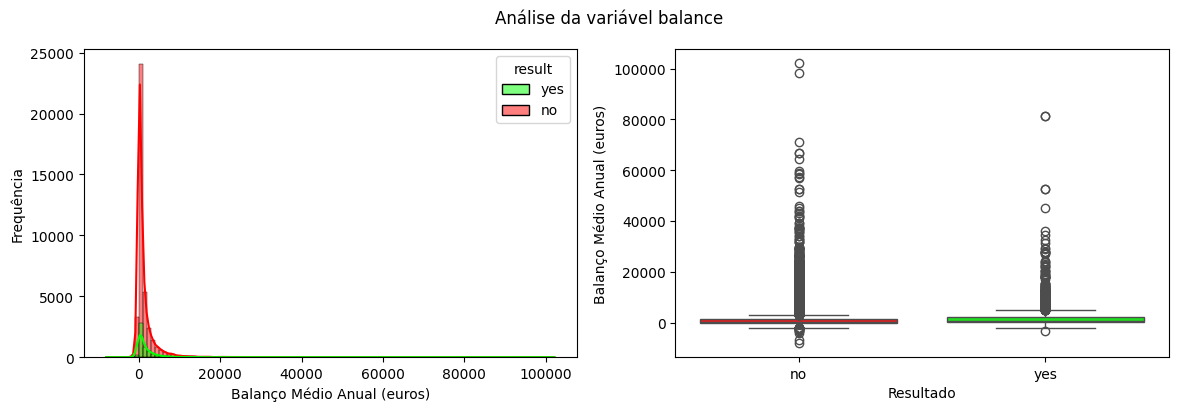

In [528]:
figsize = (14, 4)
variable = 'balance'
binwidth = 1000
label = 'Balanço Médio Anual (euros)'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

E agora passa a ser:

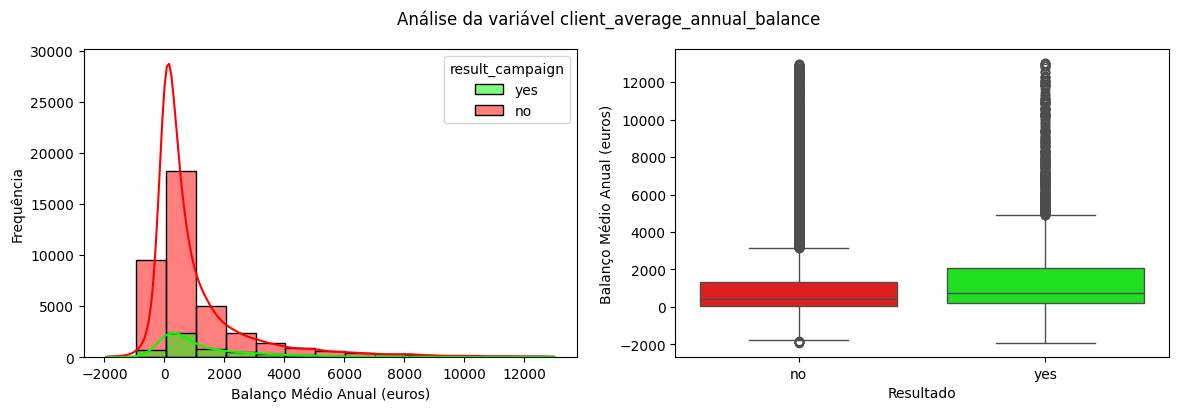

In [529]:
figsize = (14, 4)
variable = 'client_average_annual_balance'
binwidth = 1000
label = 'Balanço Médio Anual (euros)'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers, variable, binwidth, label, target)

### number_contacts_campaign

A seguir, iremos analisar com mais detalhes a distribuição da variável number_contacts_campaign:

In [530]:
Q1 = df_without_outliers['number_contacts_campaign'].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['number_contacts_campaign'].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower bound: -2.0
Upper bound: 6.0


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -2 ou superior a 6. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [531]:
lowers = df_without_outliers[(df_without_outliers['number_contacts_campaign'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['number_contacts_campaign'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 3026


Nenhum registro está abaixo do limite inferior. No entanto, 3026 registros seriam eliminados se removessemos os registros a cima do limite superior. 3026 registros é uma quantidade significativamente maior e precisa ser analisada mais de perto para entender a natureza desses registros.

Vejamos os registros acima do limite superior:

In [532]:
uppers['number_contacts_campaign'].sort_values()

,number_contacts_campaign
1917,7
1905,7
1579,7
2290,7
2289,7
...,...
18713,50
4299,51
5073,55
11914,58


O intervalo de valores vai de 7 até 63 contatos, uma diferença consideravelmente grande. Vejamos a distribuição desses valores:

In [533]:
print("25% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['number_contacts_campaign'].quantile(0.9))

25% dos valores extremos superiores: 8.0
50% dos valores extremos superiores: 9.0
75% dos valores extremos superiores: 13.0
90% dos valores extremos superiores: 19.0


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 19 e 63. Um funcionário do banco saberia informar se são números distantes da quantidade de vezes que os clientes são contactados em uma campanha. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando o novo limite superior:

In [534]:
upper_bound = uppers['number_contacts_campaign'].quantile(0.9)
uppers['number_contacts_campaign'][uppers.number_contacts_campaign > upper_bound].sort_values()

,number_contacts_campaign
31136,20
23405,20
8685,20
23108,20
23097,20
...,...
18713,50
4299,51
5073,55
11914,58


De 3026 reduzimos para apenas 283 registros que serão removidos do dataset.

In [535]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.number_contacts_campaign >= lower_bound) &
    (df_without_outliers.number_contacts_campaign <= upper_bound)
]

Total de registros no dataframe restante:

In [536]:
len(df_without_outliers)

44439

A distribuição anterior da variável number_contacts_campaign era:

---



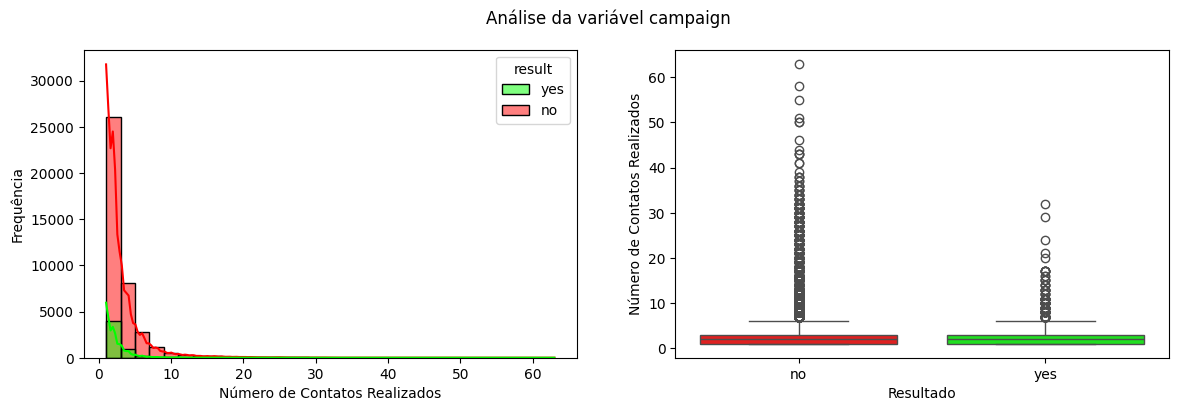

In [537]:
figsize = (14, 4)
variable = 'campaign'
binwidth = 2
label = 'Número de Contatos Realizados'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df, variable, binwidth, label, target)

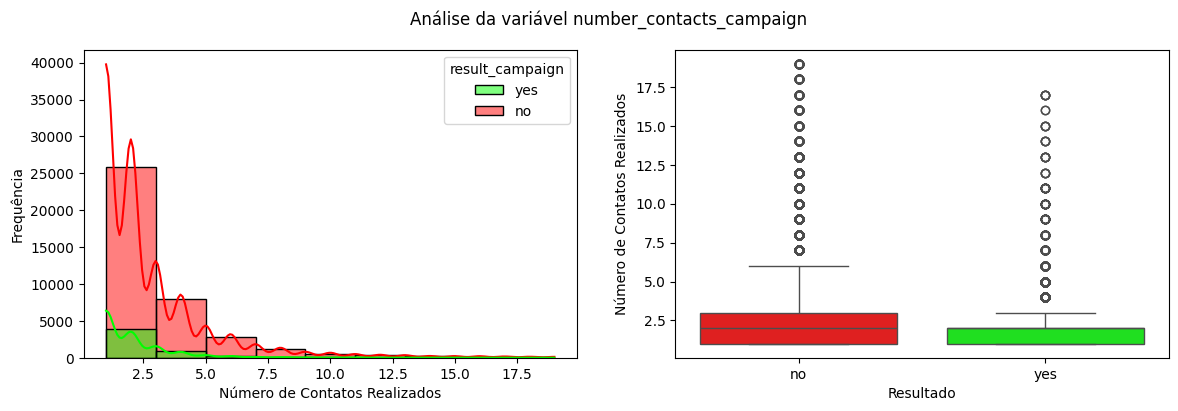

In [538]:
figsize = (14, 4)
variable = 'number_contacts_campaign'
binwidth = 2
label = 'Número de Contatos Realizados'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers, variable, binwidth, label, target)

### days_last_contact

A seguir, iremos analisar com mais detalhes a distribuição da variável number_contacts_campaign:

In [539]:
Q1 = df_without_outliers['days_last_contact'][df_without_outliers.days_last_contact > 0].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['days_last_contact'][df_without_outliers.days_last_contact > 0].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 133.0
Q3: 328.0
IQR: 195.0
Lower bound: -159.5
Upper bound: 620.5


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -159.5 ou superior a 620.5. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [540]:
lowers = df_without_outliers[(df_without_outliers['days_last_contact'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['days_last_contact'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 49


Nenhum registro está abaixo do limite inferior. E, diferente dos registros anteriores, apenas 49 registros seriam eliminados se removessemos os registros a cima do limite superior. Vejamos os registros acima do limite superior:

In [541]:
uppers['days_last_contact'].sort_values().head()

,days_last_contact
43404,626
43586,633
43507,648
43884,651
44546,651


In [542]:
uppers['days_last_contact'].sort_values().tail()

,days_last_contact
44785,838
44858,842
44837,850
44829,854
45146,871


Aplicando limites:

In [543]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.days_last_contact >= lower_bound) &
    (df_without_outliers.days_last_contact <= upper_bound)
]

Total de registros restantes:

In [544]:
len(df_without_outliers)

44390

A distribuição anterior da variável days_last_contact era:

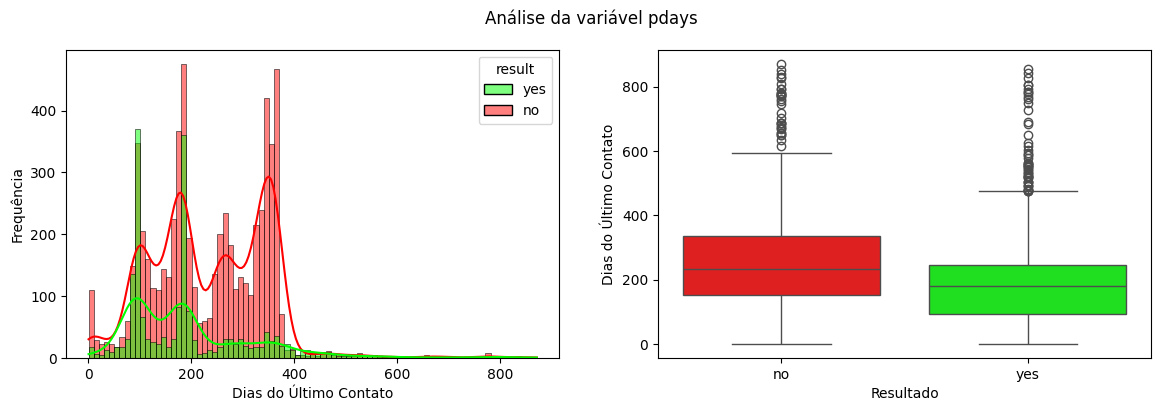

In [558]:
figsize = (14, 4)
variable = 'pdays'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[df.pdays > 0], variable, binwidth, label, target)

E agora passa a ser:

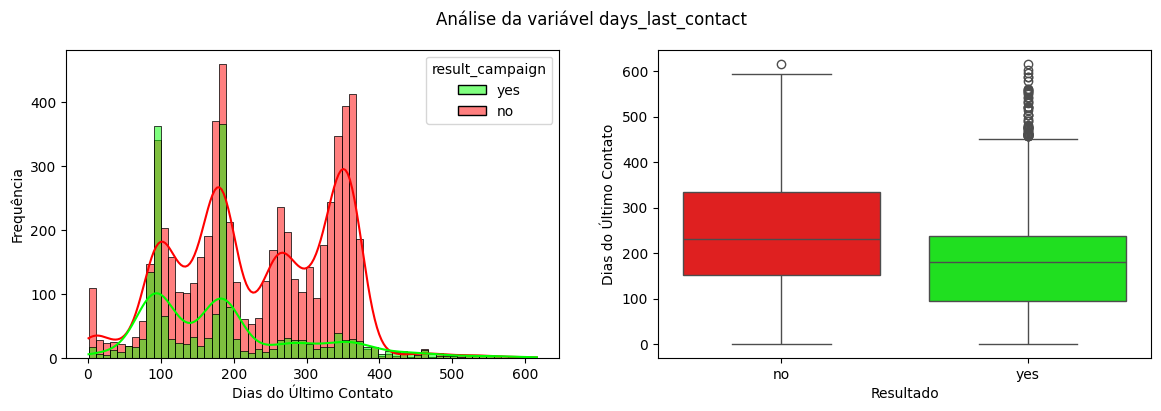

In [559]:
figsize = (14, 4)
variable = 'days_last_contact'
binwidth = 10
label = 'Dias do Último Contato'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers[df_without_outliers.days_last_contact > 0], variable, binwidth, label, target)

Como poucos registros foram considerados como outliers, não tivemos uma diferença tão grande entre os gráficos.

### number_contacts_previous_campaign

A seguir, iremos analisar com mais detalhes a distribuição da variável number_contacts_previous_campaign:

In [547]:
Q1 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)

Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5


Observe que, pelo cálculo do IQR seriam considerados outliers os registros com valor inferior a -3.5 ou superior a 8.5. Vejamos quantos registros seriam eliminados se aplicássemos esse intervalo:

In [548]:
lowers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Número de valores extremos inferiores: 0
Número de valores extremos superiores: 445


Nenhum registro está abaixo do limite inferior. 445 registros seriam eliminados se removessemos os registros a cima do limite superior. Mesmo sendo poucos registros, precisamos avaliar melhor o resultado.

In [549]:
uppers['number_contacts_previous_campaign'].sort_values()

,number_contacts_previous_campaign
27177,9
26400,9
44703,9
27624,9
44420,9
...,...
37567,38
42611,40
28886,51
38326,58


O intervalo de valores vai de 9 até 275 contatos, uma diferença consideravelmente grande, embora, apenas um registro seja 275. Iremos remover apenas esse registro para avaliar a distribuição.

In [550]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.number_contacts_previous_campaign < 275)
]

In [551]:
Q1 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.25)
print("Q1:", Q1)
Q3 = df_without_outliers['number_contacts_previous_campaign'][df_without_outliers.number_contacts_previous_campaign > 0].quantile(0.75)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
print("Lower bound:", lower_bound)
upper_bound = Q3 + 1.5 * IQR
print("Upper bound:", upper_bound)
lowers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] < lower_bound)]
print("Número de valores extremos inferiores:", len(lowers))
uppers = df_without_outliers[(df_without_outliers['number_contacts_previous_campaign'] > upper_bound)]
print("Número de valores extremos superiores:", len(uppers))

Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5
Número de valores extremos inferiores: 0
Número de valores extremos superiores: 444


Mesmo removendo o valor mais extremo, não houve mudança na análise dos outliers.

Analisando a distribuição:

In [552]:
print("25% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.25))
print("50% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.50))
print("75% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.75))
print("90% dos valores extremos superiores:", uppers['number_contacts_previous_campaign'].quantile(0.9))

25% dos valores extremos superiores: 10.0
50% dos valores extremos superiores: 11.5
75% dos valores extremos superiores: 15.0
90% dos valores extremos superiores: 22.0


Observamos que os valores mais extremos se encontram depois de 90% dos registros considerados como outliers. A partir de 90%, temos valores entre 22 e 58. Um funcionário do banco saberia informar se são números distantes da quantidade de vezes que os clientes são contactados em uma campanha. Mas, para esse trabalho, iremos considerar que os registros acima de 90% são considerados outliers. Os demais registros serão considerados como válidos.

Para minimizar a presença desses outliers, esta variável será discretizada na etapa seguinte.

Aplicando novo limite superior:

In [553]:
upper_bound = uppers['number_contacts_previous_campaign'].quantile(0.9)
uppers['number_contacts_previous_campaign'][uppers.number_contacts_previous_campaign > upper_bound].sort_values()

,number_contacts_previous_campaign
28386,23
29481,23
34691,23
34944,23
37248,23
38043,23
44367,23
28591,24
38573,24
37236,24


In [554]:
df_without_outliers = df_without_outliers[
    (df_without_outliers.number_contacts_previous_campaign >= lower_bound) &
    (df_without_outliers.number_contacts_previous_campaign <= upper_bound)
]

Tamanho final do dataset:

In [555]:
len(df_without_outliers)

44348

A distribuição anterior da variável era:

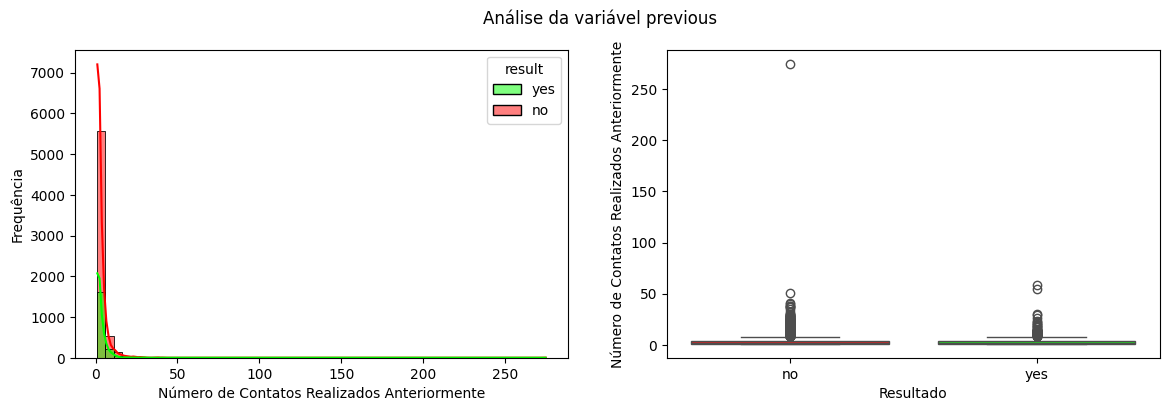

In [560]:
figsize = (14, 4)
variable = 'previous'
binwidth = 5
label = 'Número de Contatos Realizados Anteriormente'
target = 'result'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df[df.previous > 0], variable, binwidth, label, target)

E passou a ser:

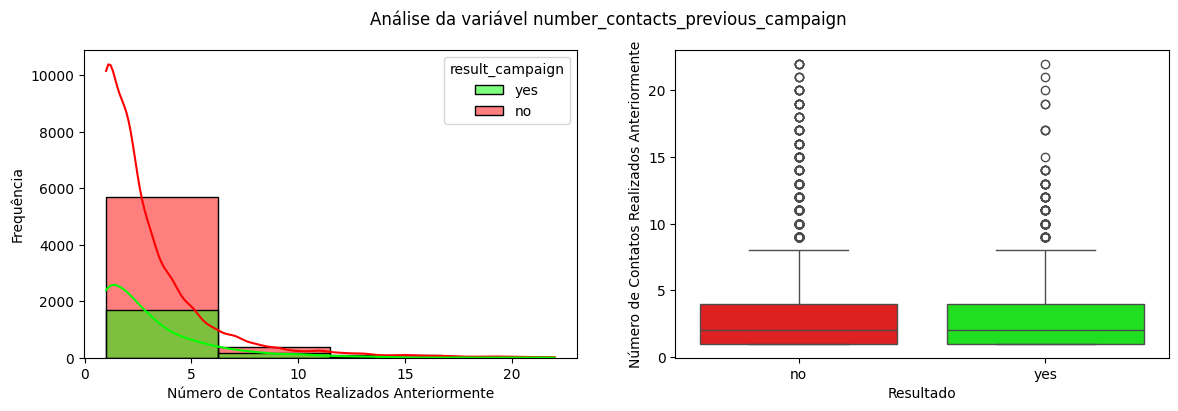

In [561]:
figsize = (14, 4)
variable = 'number_contacts_previous_campaign'
binwidth = 5
label = 'Número de Contatos Realizados Anteriormente'
target = 'result_campaign'
plot_hist_boxplot_by_binwidth_hue_result(figsize, df_without_outliers[df_without_outliers.number_contacts_previous_campaign > 0], variable, binwidth, label, target)

## Discretizar colunas contínuas

In [407]:
df_discretizado = df_without_outliers.copy()

### client_age

In [408]:
# age (idade): por faixa etária
bins = [0, 17, 24, 39, 59, 100]
labels = ['Criança/Adolescente', 'Jovem', 'Adulto', 'Meia-idade', 'Idoso']
df_discretizado['client_age_group'] = pd.cut(df_discretizado['client_age'], bins=bins, labels=labels, right=True).cat.remove_unused_categories()
df_discretizado.groupby('client_age_group', observed=True).size()

,0
client_age_group,
Jovem,803
Adulto,22163
Meia-idade,19651
Idoso,1731


### contact_day_of_month

In [409]:
bins = [0, 7, 14, 21, 27, 31]
labels = ['week 1', 'week 2', 'week 3', 'week 4', 'week 5']
df_discretizado['contact_week'] = pd.cut(df_discretizado['contact_day_of_month'], bins=bins, labels=labels, right=True).cat.remove_unused_categories()
df_discretizado.groupby('contact_week', observed=True).size()

,0
contact_week,
week 1,9655
week 2,10309
week 3,13603
week 4,5194
week 5,5587


### client_average_annual_balance

In [410]:
df_discretizado['client_average_annual_balance_group'] = pd.qcut(df_discretizado['client_average_annual_balance'][df_discretizado.client_average_annual_balance >= 0], q=4, duplicates = 'drop')
df_discretizado['client_average_annual_balance_group'] = df_discretizado['client_average_annual_balance_group'].cat.add_categories(['negative'])
df_discretizado['client_average_annual_balance_group'] = df_discretizado['client_average_annual_balance_group'].fillna('negative')
df_discretizado.groupby('client_average_annual_balance_group', observed=True).size()

,0
client_average_annual_balance_group,
"(-0.001, 144.0]",10171
"(144.0, 530.0]",10152
"(530.0, 1533.0]",10160
"(1533.0, 13014.0]",10158
negative,3707


### number_contacts_campaign

In [411]:
df_discretizado['number_contacts_campaign_group'] = pd.qcut(df_discretizado['number_contacts_campaign'], q=4, duplicates = 'drop')
df_discretizado.groupby('number_contacts_campaign_group', observed=True).size()

,0
number_contacts_campaign_group,
"(0.999, 2.0]",29658
"(2.0, 3.0]",5452
"(3.0, 19.0]",9238


### days_last_contact

In [412]:
df_discretizado['days_last_contact_group'] = pd.qcut(df_discretizado['days_last_contact'][df_discretizado.days_last_contact > 0], q=4, duplicates = 'drop')
df_discretizado['days_last_contact_group'] = df_discretizado['days_last_contact_group'].cat.add_categories(['never_before'])
df_discretizado['days_last_contact_group'] = df_discretizado['days_last_contact_group'].fillna('never_before')
df_discretizado.groupby('days_last_contact_group', observed=True).size()

,0
days_last_contact_group,
"(0.999, 131.0]",2023
"(131.0, 193.0]",2023
"(193.0, 326.0]",2038
"(326.0, 616.0]",2004
never_before,36260


### number_contacts_previous_campaign

In [413]:
df_discretizado['number_contacts_previous_campaign_group'] = pd.qcut(df_discretizado['number_contacts_previous_campaign'][df_discretizado.number_contacts_previous_campaign > 0], q=4, duplicates = 'drop')
df_discretizado['number_contacts_previous_campaign_group'] = df_discretizado['number_contacts_previous_campaign_group'].cat.add_categories(['N/A'])
df_discretizado['number_contacts_previous_campaign_group'] = df_discretizado['number_contacts_previous_campaign_group'].fillna('N/A')
df_discretizado.groupby('number_contacts_previous_campaign_group', observed=True).size()

,0
number_contacts_previous_campaign_group,
"(0.999, 2.0]",4811
"(2.0, 4.0]",1821
"(4.0, 22.0]",1456
N/A,36260


## Rebalanceamento do dataset

In [414]:
len(df_discretizado)

44348

In [415]:
df_deduplicated = df_discretizado.drop_duplicates(subset=[
    'client_age_group',
    'client_job',
    'client_marital_status',
    'client_education_level',
    'client_financial_default',
    'client_average_annual_balance_group',
    'client_housing_loan',
    'client_personal_loan',
    'contact_type',
    'contact_week',
    'contact_month',
    'number_contacts_campaign_group',
    'days_last_contact_group',
    'number_contacts_previous_campaign_group',
    'result_previous_campaign',
    'result_campaign'
], inplace=False)

In [416]:
len(df_deduplicated)

32506

In [417]:
df_deduplicated.groupby('result_campaign', dropna=False).size()

,0
result_campaign,
no,27547
yes,4959


## Transformação e validação dos dados

In [418]:
df_transformed = df_deduplicated.copy()

### Variáveis binárias

Converter variáveis categóricas 'yes'/'no' em binárias 1/0;

In [419]:
df_transformed['client_financial_default'] = df_transformed['client_financial_default'].map({'yes': 1, 'no': 0})
df_transformed['client_housing_loan'] = df_transformed['client_housing_loan'].map({'yes': 1, 'no': 0})
df_transformed['result_campaign'] = df_transformed['result_campaign'].map({'yes': 1, 'no': 0})

Converter variávieis categorias em números ordinais (ou encoder?);


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [420]:
# Inicializar o MinMaxScaler
# scaler_norm = MinMaxScaler()

In [421]:
# Aprende min e max APENAS de X_train
# scaler_norm.fit(X_train)
# X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
# X_test_normalized = scaler_norm.transform(X_test)

In [422]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
# df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [423]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
# print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):


In [424]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
# plt.figure(figsize=(8, 6))
# sns.histplot(df_normalized['sepal length (cm)'], kde=True)
# plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
# plt.xlabel('Comprimento da Sépala Normalizado')
# plt.ylabel('Frequência')
# plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

# Respondendo nossas hipóteses


## Hipótese 1

> Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?

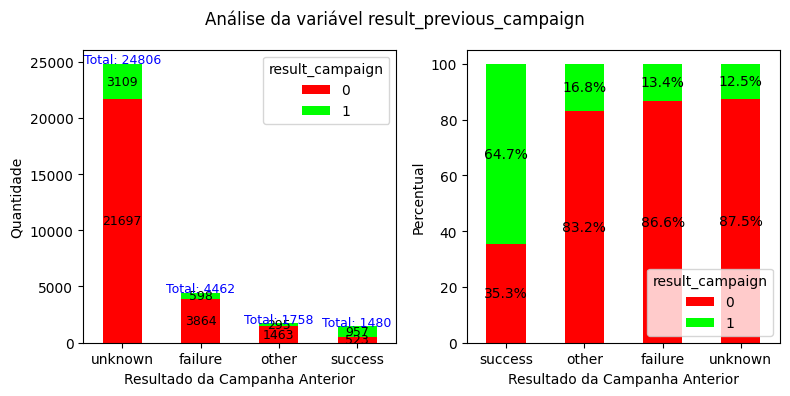

In [425]:
fig, ax = plt.subplots(1,2, figsize = (8, 4))
fig.suptitle('Análise da variável result_previous_campaign')

# plot 1
# Preparação do df
df_group = df_transformed.groupby(['result_previous_campaign', 'result_campaign'], as_index=False, dropna=False).size()
df_group['total'] = df_group.groupby('result_previous_campaign', dropna=False)['size'].transform('sum')
df_pivot = df_group.pivot(index='result_previous_campaign', columns='result_campaign', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[[1, 0]].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Resultado da Campanha Anterior')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('result_previous_campaign', dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='result_previous_campaign', columns='result_campaign', values='percent')
df_pivot = df_pivot.sort_values(by=1, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Resultado da Campanha Anterior')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

## Hipótese 2

> Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?

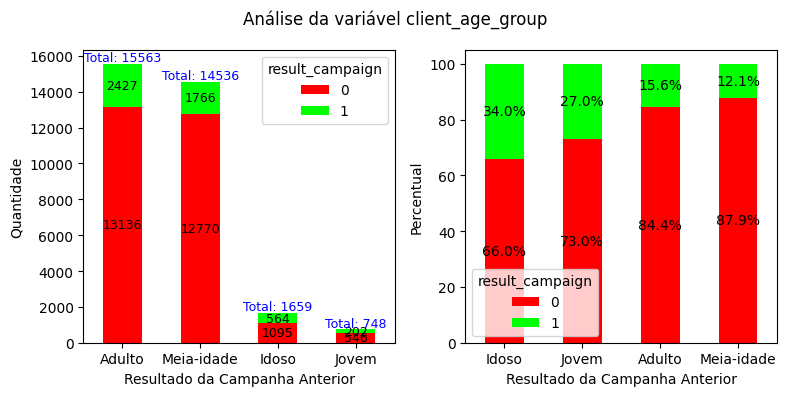

In [426]:
fig, ax = plt.subplots(1,2, figsize = (8, 4))
fig.suptitle('Análise da variável client_age_group')

# plot 1
# Preparação do df
df_group = df_transformed.groupby(['client_age_group', 'result_campaign'], as_index=False, dropna=False, observed=True).size()
df_group['total'] = df_group.groupby('client_age_group', dropna=False, observed=True)['size'].transform('sum')
df_pivot = df_group.pivot(index='client_age_group', columns='result_campaign', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[[1, 0]].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Resultado da Campanha Anterior')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('client_age_group', dropna=False, observed=True)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='client_age_group', columns='result_campaign', values='percent')
df_pivot = df_pivot.sort_values(by=1, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Resultado da Campanha Anterior')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

## Hipótese 3

> Ligar mais vezes para um cliente diminui a chance dele contratar?

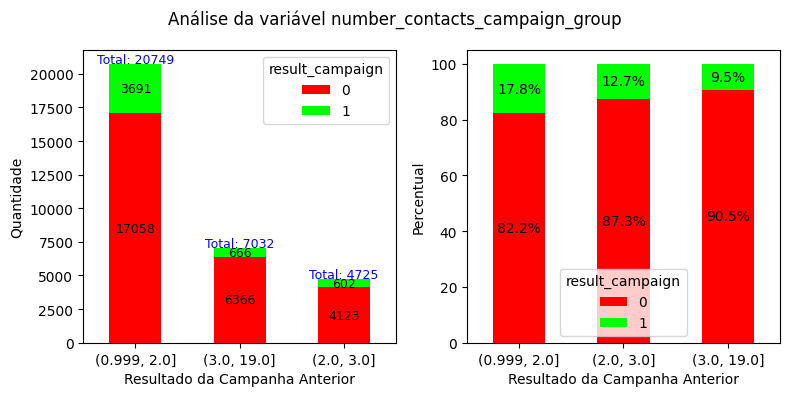

In [427]:
fig, ax = plt.subplots(1,2, figsize = (8, 4))
fig.suptitle('Análise da variável number_contacts_campaign_group')

# plot 1
# Preparação do df
df_group = df_transformed.groupby(['number_contacts_campaign_group', 'result_campaign'], as_index=False, dropna=False, observed=True).size()
df_group['total'] = df_group.groupby('number_contacts_campaign_group', dropna=False, observed=True)['size'].transform('sum')
df_pivot = df_group.pivot(index='number_contacts_campaign_group', columns='result_campaign', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[[1, 0]].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Resultado da Campanha Anterior')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('number_contacts_campaign_group', dropna=False, observed=True)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='number_contacts_campaign_group', columns='result_campaign', values='percent')
df_pivot = df_pivot.sort_values(by=1, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Resultado da Campanha Anterior')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

## Hipótese 4

> Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

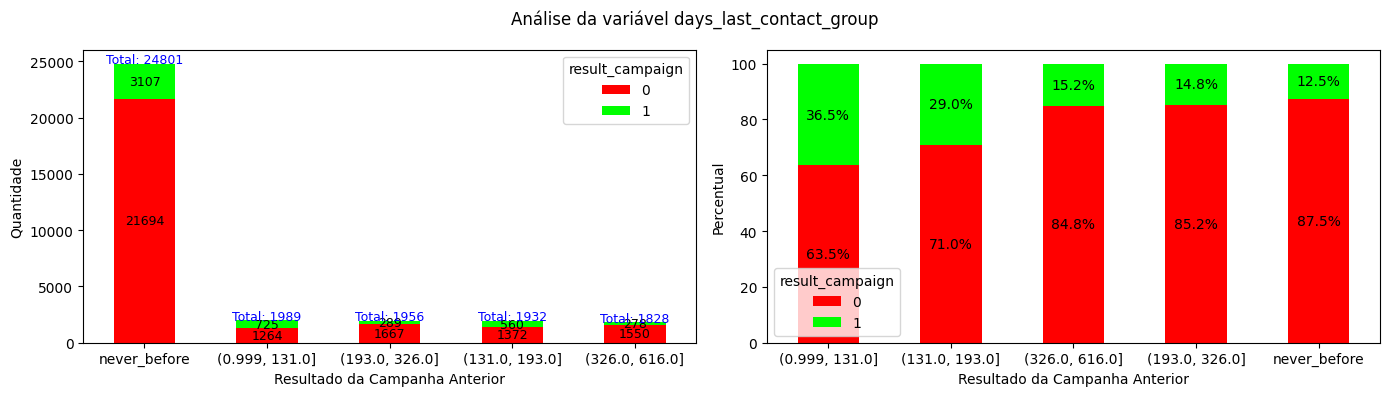

In [428]:
fig, ax = plt.subplots(1,2, figsize = (14, 4))
fig.suptitle('Análise da variável days_last_contact_group')

# plot 1
# Preparação do df
df_group = df_transformed.groupby(['days_last_contact_group', 'result_campaign'], as_index=False, dropna=False, observed=True).size()
df_group['total'] = df_group.groupby('days_last_contact_group', dropna=False, observed=True)['size'].transform('sum')
df_pivot = df_group.pivot(index='days_last_contact_group', columns='result_campaign', values='size')
df_pivot = df_pivot.sort_index(key=df_pivot[[1, 0]].sum(axis=1).get, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
ax[0].set_xlabel('Resultado da Campanha Anterior')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
    ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

# plot 2
# Preparação do df
df_group['percent'] = df_group.groupby('days_last_contact_group', dropna=False, observed=True)['size'].transform(lambda x: x / x.sum() * 100)
df_pivot = df_group.pivot(index='days_last_contact_group', columns='result_campaign', values='percent')
df_pivot = df_pivot.sort_values(by=1, ascending=False)

# plot
df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
ax[1].set_xlabel('Resultado da Campanha Anterior')
ax[1].set_ylabel('Percentual')
ax[1].tick_params(axis='x', labelrotation=0)

# Adicionando rótulos
for i, (no, yes) in enumerate(zip(df_pivot[0], df_pivot[1])):
    ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
    ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.